In [ ]:
# =============================================================================
# PIPELINE v8 — Part 1/5
# Cells [00]–[08]: Imports · Constants · Data Loading · Feature Engineering
# =============================================================================

In [ ]:
# Kết nối với Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# [00a] Pip install
# -----------------------------------------------------------------------------
%pip install -q lightgbm xgboost optuna prophet shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.1 MB/s eta 0:00:00


In [ ]:
# [00b] Imports
# -----------------------------------------------------------------------------
import os, glob, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_pinball_loss)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

import shap

print("✓ All imports OK")

✓ All imports OK


In [ ]:
# [01] Constants & Paths
# -----------------------------------------------------------------------------
# 1. Trỏ cái gốc về thư mục chứa dữ liệu của bạn
DATA_DIR            = 'input/' 

# 2. Các file đọc vào (Input) sẽ tự động lấy gốc là 'input/'
SALES_PATH          = DATA_DIR + 'sales.csv'
PROMOS_PATH         = DATA_DIR + 'promotions.csv'
TRAFFIC_PATH        = DATA_DIR + 'web_traffic.csv'
SAMPLE_SUB_PATH     = DATA_DIR + 'sample_submission.csv'

# 3. Chỗ lưu kết quả (Output)
SUBMISSION_OUT_PATH = 'final_submission.csv' 

# 4. Chỗ lưu tham số mô hình
PARAMS_DIR          = 'optuna_params/' 

# Lệnh này sẽ tự động tạo một thư mục tên là 'optuna_params' nằm cạnh file notebook của bạn nếu nó chưa tồn tại.
os.makedirs(PARAMS_DIR, exist_ok=True)

# ── Date boundaries ──────────────────────────────────────────────────────────
SHAPE_START   = pd.Timestamp('2012-07-04')
SHAPE_END     = pd.Timestamp('2022-12-31')
REGIME_START  = pd.Timestamp('2019-01-01')
TRAIN_START   = pd.Timestamp('2019-01-01')
TRAIN_END     = pd.Timestamp('2022-12-31')
TEST_START    = pd.Timestamp('2023-01-01')
TEST_END      = pd.Timestamp('2024-07-01')   # inclusive, 548 days

# ── CV Folds ─────────────────────────────────────────────────────────────────
FOLDS = {
    'fold1': {'train': ('2019-01-01', '2020-12-31'), 'val': ('2021-01-01', '2021-12-31')},
    'fold2': {'train': ('2019-01-01', '2021-12-31'), 'val': ('2022-01-01', '2022-12-31')},
}

# ── Numeric constants ────────────────────────────────────────────────────────
RANDOM_SEED        = 42
OPTUNA_TRIALS      = 100
YOY_RATIO_CLIP     = (0.3, 3.0)
LOWER_QUANTILE     = 0.10
LOWER_QUANTILE_KEY = 'lgbm_q10'
BIAS_COEF_WARN     = 1.20
COGS_RATIO_MIN     = 0.05
COGS_RATIO_MAX     = 1.65
RECENCY_WEIGHT_COEF = 0.10   # exp(coef × year_offset) for sample weights
AR_MAE_THRESHOLD    = 0.01   # 1 % improvement required to enable AR correction

# ── Scale-transform model groups ─────────────────────────────────────────────
LOG_SCALE_MODELS_NO_BIAS   = ['xgb', 'lgbm_q90', 'lgbm_q10']
LOG_SCALE_MODELS_WITH_BIAS = ['ridge_log']
# lgbm_l1, lgbm_tweedie, lgbm_hier → original scale
# xgb → log1p train, expm1 predict
# holt_winters, prophet → original scale

# ── Feature flags — every new addition is guarded here ───────────────────────
IMPROVEMENTS = {
    'lgbm_hier'             : True,   # §7/§8/§10/§12 — hierarchical LGBM
    'ridge_cv_meta'         : True,   # §9 — RidgeCV replaces NNLS (allows neg weights)
    'recency_weights'       : True,   # §7/§8/§10 — exp sample weights LGBM+XGB
    'seasonal_prior_pre2019': True,   # §3/§9 feat — (month,day) norm mean 2012-2018
    'extended_lags'         : True,   # §3 — lag 358-372 + roll_mean_28/49_safe
    'per_fold_frac'         : True,   # §8 — rebuild frac_table per fold in OOF
    'pinball_loss'          : True,   # §7 — quantile objective uses mean_pinball_loss
    'traffic_train_median'  : True,   # §3 — traffic fillna uses train-period median
    'ar_fold_gate'          : True,   # §9b — AR correction only if fold2 validated
    'cogs_meta_blend'       : True,   # §11 — learned COGS blend weights (LOO-CV)
}

print("✓ Constants OK")
print(f"  IMPROVEMENTS enabled: {[k for k,v in IMPROVEMENTS.items() if v]}")

✓ Constants OK
  IMPROVEMENTS enabled: ['lgbm_hier', 'ridge_cv_meta', 'recency_weights', 'seasonal_prior_pre2019', 'extended_lags', 'per_fold_frac', 'pinball_loss', 'traffic_train_median', 'ar_fold_gate', 'cogs_meta_blend']


In [ ]:
# [02] Load Data & Sanity Checks
# -----------------------------------------------------------------------------
sales   = pd.read_csv(SALES_PATH,       parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
promos  = pd.read_csv(PROMOS_PATH,      parse_dates=['start_date', 'end_date'])
traffic = pd.read_csv(TRAFFIC_PATH,     parse_dates=['date'])
sub     = pd.read_csv(SAMPLE_SUB_PATH,  parse_dates=['Date'])

# ── Master date range frame ───────────────────────────────────────────────────
all_dates = pd.date_range(SHAPE_START, TEST_END, freq='D')
df = pd.DataFrame({'Date': all_dates})
df = df.merge(sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')
df['is_train']       = ((df['Date'] >= TRAIN_START) & (df['Date'] <= TRAIN_END))
df['log1p_Revenue']  = np.log1p(df['Revenue'])

# ── Sanity ───────────────────────────────────────────────────────────────────
assert sales['Date'].nunique() == len(sales), "Duplicate dates in sales"
assert sales[(sales['Date'] >= TRAIN_START) & (sales['Date'] <= TRAIN_END)]['Revenue'].isna().sum() == 0
assert len(sub) == 548
assert sub['Date'].iloc[-1] == pd.Timestamp('2024-07-01')
print(f"Sales range:  {sales['Date'].min().date()} → {sales['Date'].max().date()}")
print(f"Train rows:   {sales[(sales['Date']>=TRAIN_START)&(sales['Date']<=TRAIN_END)].shape[0]}  (expect 1461)")
print(f"df master:    {len(df)} rows  ({df['Date'].min().date()} → {df['Date'].max().date()})")
print(f"Submission:   {len(sub)} rows")

Sales range:  2012-07-04 → 2022-12-31
Train rows:   1461  (expect 1461)
df master:    4381 rows  (2012-07-04 → 2024-07-01)
Submission:   548 rows


In [ ]:
# [03] Calendar Features
# -----------------------------------------------------------------------------
def build_calendar_features(df):
    df = df.copy()
    d  = df['Date']

    df['dom']           = d.dt.day
    df['month']         = d.dt.month
    df['year']          = d.dt.year
    df['dow']           = d.dt.dayofweek        # 0 = Mon
    df['is_weekend']    = (df['dow'] >= 5).astype(int)
    df['doy']           = d.dt.dayofyear
    df['days_in_month'] = d.dt.days_in_month
    df['woy']           = d.dt.isocalendar().week.astype(int)

    # Fourier harmonics (annual cycle)
    for k in [1, 2]:
        df[f'fourier_sin_{k}'] = np.sin(2 * np.pi * k * df['doy'] / 365.25)
        df[f'fourier_cos_{k}'] = np.cos(2 * np.pi * k * df['doy'] / 365.25)

    # BOM / EOM / DIP flags
    df['is_bom']        = (df['dom'] <= 3).astype(int)
    df['is_eom']        = (df['dom'] >= 28).astype(int)
    df['dip_bom']       = ((df['dom'] >= 4) & (df['dom'] <= 10)).astype(int)
    df['days_to_eom']   = (df['days_in_month'] - df['dom']).clip(0, 5)
    df['days_from_bom'] = (df['dom'] - 1).clip(0, 5)
    df['eom_month']     = df['is_eom'] * df['month']
    df['bom_month']     = df['is_bom'] * df['month']

    # Trend
    origin              = pd.Timestamp('2019-01-01')
    df['t_linear']      = (df['Date'] - origin).dt.days.clip(lower=0)

    # Regime / parity
    df['is_post2019']      = (df['year'] >= 2019).astype(int)
    df['is_odd_year']      = (df['year'] % 2 == 1).astype(int)
    df['is_odd']           = df['is_odd_year']          # alias for frac lookups
    df['is_urban_blowout'] = ((df['is_odd_year'] == 1) & (df['month'] == 8)).astype(int)

    return df

df = build_calendar_features(df)
print(f"✓ Calendar features: {[c for c in df.columns if c not in ['Date','Revenue','COGS','log1p_Revenue','is_train']]}")

✓ Calendar features: ['dom', 'month', 'year', 'dow', 'is_weekend', 'doy', 'days_in_month', 'woy', 'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2', 'is_bom', 'is_eom', 'dip_bom', 'days_to_eom', 'days_from_bom', 'eom_month', 'bom_month', 't_linear', 'is_post2019', 'is_odd_year', 'is_odd', 'is_urban_blowout']


In [ ]:
# [04] Promo Features — Pass 1
# -----------------------------------------------------------------------------
def build_promo_features_pass1(df, promos):
    """Expand promotions → daily; keep highest discount per day; lift_score=0 placeholder."""
    promo_daily = []
    for _, row in promos.iterrows():
        for d in pd.date_range(row['start_date'], row['end_date'], freq='D'):
            promo_daily.append({
                'Date'           : d,
                'promo_type'     : row['promo_type'],
                'discount_value' : row['discount_value'],
                'stackable_flag' : row['stackable_flag'],
                'min_order_value': row.get('min_order_value', 0) or 0,
            })

    promo_df = (pd.DataFrame(promo_daily)
                .sort_values('discount_value', ascending=False)
                .drop_duplicates('Date', keep='first'))

    df = df.merge(promo_df, on='Date', how='left')
    df['is_promo']           = df['discount_value'].notna().astype(int)
    df['discount_value']     = df['discount_value'].fillna(0.0)
    df['stackable_flag']     = df['stackable_flag'].fillna(0).astype(int)
    df['min_order_value']    = df['min_order_value'].fillna(0.0)
    df['promo_lift_score']   = 0.0

    season_map = {
        'Spring_Sale': 'Spring',     'Spring_Promotion': 'Spring',
        'Mid_Year_Sale': 'Mid-Year', 'Mid_Year_Clearance': 'Mid-Year',
        'Year_End_Sale': 'Year-End', 'Year_End_Blowout': 'Year-End',
        'Urban_Blowout': 'Urban_Blowout',
    }
    df['promo_season'] = df['promo_type'].map(season_map).fillna('Other')

    # Days relative to promo window
    df['days_since_promo_start'] = 0
    df['days_until_promo_end']   = 0
    for _, row in promos.iterrows():
        mask = (df['Date'] >= row['start_date']) & (df['Date'] <= row['end_date'])
        df.loc[mask, 'days_since_promo_start'] = (df.loc[mask, 'Date'] - row['start_date']).dt.days
        df.loc[mask, 'days_until_promo_end']   = (row['end_date'] - df.loc[mask, 'Date']).dt.days

    # Monthly promo flag
    df['ym'] = df['Date'].dt.to_period('M')
    promo_months = set(df[df['is_promo'] == 1]['ym'])
    df['is_promo_month'] = df['ym'].isin(promo_months).astype(int)
    df.drop(columns=['ym'], inplace=True)

    return df

df = build_promo_features_pass1(df, promos)
print(f"✓ Promo pass1 done — promo days: {df['is_promo'].sum()}")

✓ Promo pass1 done — promo days: 1707


In [ ]:
# [05] Dynamic Lift Map
# -----------------------------------------------------------------------------
def compute_dynamic_lift_map(df, min_n=5):
    FALLBACK = {'Spring': 1.20, 'Mid-Year': 1.05, 'Year-End': 0.85,
                'Urban_Blowout': 0.75, 'Other': 1.0}

    hist = df[(df['Date'] >= SHAPE_START) & (df['Date'] <= TRAIN_END) &
              df['Revenue'].notna()].copy()

    baseline = (hist[hist['is_promo'] == 0]
                .groupby(['month', 'is_post2019'])['Revenue']
                .median().to_dict())

    promo_rows = hist[hist['is_promo'] == 1].copy()
    promo_rows['baseline'] = promo_rows.apply(
        lambda r: baseline.get((r['month'], r['is_post2019']), np.nan), axis=1)
    promo_rows = promo_rows[promo_rows['baseline'].notna() & (promo_rows['baseline'] > 0)]
    promo_rows['lift'] = promo_rows['Revenue'] / promo_rows['baseline']

    lift_map = {}
    for season in promo_rows['promo_season'].unique():
        vals = promo_rows[promo_rows['promo_season'] == season]['lift']
        if len(vals) >= min_n:
            lift_map[season] = float(np.median(vals))
            print(f"  LIFT_MAP[{season}] = {lift_map[season]:.4f}  (n={len(vals)})")
        else:
            lift_map[season] = FALLBACK.get(season, 1.0)
            print(f"  LIFT_MAP[{season}] = {lift_map[season]:.4f}  (fallback, n={len(vals)})")

    return lift_map

lift_map = compute_dynamic_lift_map(df)

  LIFT_MAP[Other] = 0.9327  (n=1463)


In [ ]:
# [06] Promo Features — Pass 2
# -----------------------------------------------------------------------------
def build_promo_features_pass2(df, lift_map):
    df = df.copy()
    df['promo_lift_score'] = df['promo_season'].map(lift_map).fillna(1.0)
    df.loc[df['is_promo'] == 0, 'promo_lift_score'] = 1.0
    return df

df = build_promo_features_pass2(df, lift_map)
print(f"✓ Promo pass2 done — lift_score range: [{df['promo_lift_score'].min():.3f}, {df['promo_lift_score'].max():.3f}]")

✓ Promo pass2 done — lift_score range: [0.933, 1.000]


In [ ]:
# [07] Traffic Features
# -----------------------------------------------------------------------------
def build_traffic_features(df, traffic):
    """
    sessions_lag365: sessions same day prior year.
    FIX: fillna with TRAIN-period median (not full-df median) to prevent
         test-period statistics leaking into the median estimate.
    """
    sessions = (traffic.groupby('date')['sessions'].sum()
                .reset_index().rename(columns={'date': 'Date'}))
    sessions = sessions.set_index('Date')['sessions']

    df = df.copy()
    df['sessions_lag365'] = df['Date'].apply(
        lambda d: sessions.get(d - pd.Timedelta(days=365), np.nan)
    )

    # Clip outliers
    p99 = df['sessions_lag365'].quantile(0.99)
    df['sessions_lag365'] = df['sessions_lag365'].clip(upper=p99)

    if IMPROVEMENTS['traffic_train_median']:
        train_median = df.loc[df['is_train'], 'sessions_lag365'].median()
    else:
        train_median = df['sessions_lag365'].median()
    df['sessions_lag365'] = df['sessions_lag365'].fillna(train_median)

    return df

df = build_traffic_features(df, traffic)
print(f"✓ Traffic features — sessions_lag365 NaN: {df['sessions_lag365'].isna().sum()}")

✓ Traffic features — sessions_lag365 NaN: 0


In [ ]:
# [08] Lag Features
# -----------------------------------------------------------------------------
def build_lag_features(df, revenue_series):
    """
    revenue_series: pd.Series with index=Date (or dict-like .get()).
    During inference this series is updated daily with predicted values.
    Avoid lag_1 to prevent error propagation.

    NEW (IMPROVEMENTS['extended_lags']):
      - Individual lags for days 358–372 (window around ±1 week of lag_365)
      - roll_mean_28_safe / roll_mean_49_safe: rolling mean on lag_365 series
        with min_periods=14/28 so they remain valid on short training splits.
    """
    df = df.copy()

    # ── Core lags ────────────────────────────────────────────────────────────
    for lag in [364, 365, 366, 730]:
        df[f'lag_{lag}'] = df['Date'].apply(
            lambda d, l=lag: revenue_series.get(d - pd.Timedelta(days=l), np.nan))

    # YoY ratio (trending signal)
    df['yoy_ratio'] = (df['lag_365'] / df['lag_730'].replace(0, np.nan)).clip(*YOY_RATIO_CLIP)

    # ── Rolling windows on lag_365 series ────────────────────────────────────
    lag365 = df.set_index('Date')['lag_365'].sort_index()

    for window, funcs in [
        (7,  ['mean', 'median', 'std', 'max']),
        (14, ['median']),
        (30, ['mean']),
    ]:
        for func in funcs:
            rolled = lag365.rolling(window=window, min_periods=1)
            vals   = getattr(rolled, func)()
            if func == 'std':
                vals = vals.fillna(0)
            df[f'roll{window}_{func}_lag365'] = df['Date'].map(vals)

    # ── Log transforms ────────────────────────────────────────────────────────
    df['log_lag_365'] = np.log1p(df['lag_365'].fillna(0))
    df['log_lag_730'] = np.log1p(df['lag_730'].fillna(0))
    df['lag365_t']    = df['lag_365'] * df['t_linear'] / 1e9   # cross-year drift

    # ── Extended lags 358–372 (IMPROVEMENTS['extended_lags']) ────────────────
    if IMPROVEMENTS['extended_lags']:
        for lag in range(358, 373):          # 358, 359, ..., 372 (15 lags)
            df[f'lag_{lag}'] = df['Date'].apply(
                lambda d, l=lag: revenue_series.get(d - pd.Timedelta(days=l), np.nan))

        # roll_mean_28_safe / roll_mean_49_safe
        # min_periods ensures availability on short fold splits
        df['roll_mean_28_safe'] = df['Date'].map(
            lag365.rolling(28, min_periods=14).mean())
        df['roll_mean_49_safe'] = df['Date'].map(
            lag365.rolling(49, min_periods=28).mean())

    return df


# Build initial lag features on the master df using actual sales history
_revenue_series_init = sales.set_index('Date')['Revenue']
df = build_lag_features(df, _revenue_series_init)
print(f"✓ Lag features built — lag_365 NaN in train: "
      f"{df.loc[df['is_train'], 'lag_365'].isna().sum()}")

✓ Lag features built — lag_365 NaN in train: 0


In [ ]:
# [08b] Seasonal Prior Pre-2019 Feature
# -----------------------------------------------------------------------------
def build_seasonal_prior_pre2019(df, sales):
    """
    NEW (IMPROVEMENTS['seasonal_prior_pre2019']):
    Compute a (month, day) normalized mean from the pre-2019 era (2012–2018).
    Normalization: for each month, divide by the mean of all days in that month
    so the feature represents *relative within-month position* (1.0 = average day).
    This captures long-run seasonality without leaking post-2019 structure.
    """
    if not IMPROVEMENTS['seasonal_prior_pre2019']:
        return df

    pre = sales[(sales['Date'] >= pd.Timestamp('2012-08-01')) &
                (sales['Date'] <  pd.Timestamp('2019-01-01'))].copy()
    pre['month'] = pre['Date'].dt.month
    pre['dom']   = pre['Date'].dt.day

    # Mean revenue per (month, dom)
    cell_mean  = pre.groupby(['month', 'dom'])['Revenue'].mean()
    month_mean = pre.groupby('month')['Revenue'].mean()

    lookup = {}
    for (month, dom), rev in cell_mean.items():
        denom = month_mean.get(month, np.nan)
        lookup[(month, dom)] = (rev / denom) if (denom and denom > 0) else 1.0

    df = df.copy()
    df['seasonal_prior_pre2019'] = df.apply(
        lambda r: lookup.get((r['month'], r['dom']), 1.0), axis=1
    )
    n_filled = (df['seasonal_prior_pre2019'] != 1.0).sum()
    print(f"  seasonal_prior_pre2019: {n_filled} non-trivial cells, "
          f"range [{df['seasonal_prior_pre2019'].min():.3f}, {df['seasonal_prior_pre2019'].max():.3f}]")
    return df

df = build_seasonal_prior_pre2019(df, sales)
print("✓ Seasonal prior pre-2019 done")

  seasonal_prior_pre2019: 4381 non-trivial cells, range [0.302, 2.462]
✓ Seasonal prior pre-2019 done


In [ ]:
# [09] Optuna cache helper  (defined here, used throughout)
# -----------------------------------------------------------------------------
def get_or_run_study(study_name, objective_fn, X_tr, y_tr, X_val, y_val,
                     n_trials=OPTUNA_TRIALS):
    """
    Cache best params to PARAMS_DIR. Re-uses saved params if present.
    Returns dict of best hyperparams.
    """
    cache_path = os.path.join(PARAMS_DIR, f'best_params_{study_name}.pkl')
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            params = pickle.load(f)
        print(f"  [cache hit] {study_name}: {params}")
        return params

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        study_name=study_name,
    )
    study.optimize(
        lambda trial: objective_fn(trial, X_tr, y_tr, X_val, y_val),
        n_trials=n_trials,
        show_progress_bar=False,
    )
    params = study.best_params
    with open(cache_path, 'wb') as f:
        pickle.dump(params, f)
    print(f"  [new study] {study_name}: best_val={study.best_value:.4f}  params={params}")
    return params

print("✓ Part 1 complete — all feature engineering functions defined")
print("=" * 70)
print("HANDOFF STATE:")
print("  df          — master frame with all features (shape, train, test)")
print("  sales       — raw daily revenue/COGS")
print("  promos      — raw promotions")
print("  traffic     — raw web traffic")
print("  sub         — sample submission (548 rows)")
print("  lift_map    — dynamic promo lift ratios")
print("  IMPROVEMENTS — feature flag dict")
print("  get_or_run_study() — Optuna cache helper")
print("\nNext → Part 2: Feature lists, Frac table, Monthly features,")
print("              L1 LGBM Optuna, Monthly ensemble, Monthly baseline build")

✓ Part 1 complete — all feature engineering functions defined
HANDOFF STATE:
  df          — master frame with all features (shape, train, test)
  sales       — raw daily revenue/COGS
  promos      — raw promotions
  traffic     — raw web traffic
  sub         — sample submission (548 rows)
  lift_map    — dynamic promo lift ratios
  IMPROVEMENTS — feature flag dict
  get_or_run_study() — Optuna cache helper

Next → Part 2: Feature lists, Frac table, Monthly features,
              L1 LGBM Optuna, Monthly ensemble, Monthly baseline build


In [ ]:
# =============================================================================
# PIPELINE v8 — Part 2/5
# Cells [09]–[16]: Feature Lists · Frac Table · Monthly Features ·
#                  L1 LGBM Optuna · Monthly Ensemble OOF · Monthly Baseline
# =============================================================================
# ASSUMES Part 1 has run — df, sales, promos, traffic, lift_map all in scope.

In [ ]:
# [09] Feature Lists
# -----------------------------------------------------------------------------

# ── L1: Monthly LGBM (48 obs; num_leaves=8 hardcap) ─────────────────────────
# lag_same_parity excluded — identical to lag_24m (EDA verified)
L1_FEATURES = [
    'month', 'year', 'is_odd_year',
    'fourier_sin_1', 'fourier_cos_1',
    'is_promo_month', 'lag_12m', 'lag_24m',
    'yoy_ratio_monthly', 't_linear_monthly',
    'odd_month',           # is_odd_year × month — captures Aug-odd interaction
]

# ── L2: Daily models (1461 training rows) ────────────────────────────────────
L2_FEATURES = [
    # calendar
    'dom', 'month', 'year', 'dow', 'is_weekend', 'doy', 'days_in_month',
    'fourier_sin_1', 'fourier_cos_1', 'fourier_cos_2',
    'is_bom', 'is_eom', 'days_to_eom', 'days_from_bom',
    'eom_month', 'bom_month', 'dip_bom',
    't_linear', 'is_post2019', 'is_odd_year',
    # core lags
    'lag_364', 'lag_365', 'lag_366', 'lag_730', 'lag365_t',
    'roll7_mean_lag365', 'roll7_median_lag365', 'roll7_std_lag365', 'roll7_max_lag365',
    'roll14_median_lag365', 'roll30_mean_lag365',
    'log_lag_365', 'log_lag_730',
    # promo
    'is_promo', 'discount_value', 'promo_lift_score',
    'days_since_promo_start', 'days_until_promo_end',
    'stackable_flag', 'min_order_value',
    # traffic
    'sessions_lag365',
    # L1 monthly anchor — MUST exist before L2 Optuna
    'monthly_baseline',
]

# Extended lags 358-372 + safe rolling
if IMPROVEMENTS['extended_lags']:
    # Define core lags to be excluded from extended lags to avoid duplication
    _core_lags_present = ['lag_364', 'lag_365', 'lag_366']

    _ext_lags = [f'lag_{l}' for l in range(358, 373) if f'lag_{l}' not in _core_lags_present]
    _ext_rolls = ['roll_mean_28_safe', 'roll_mean_49_safe']
    L2_FEATURES = L2_FEATURES + _ext_lags + _ext_rolls

# Seasonal prior pre-2019
if IMPROVEMENTS['seasonal_prior_pre2019']:
    L2_FEATURES = L2_FEATURES + ['seasonal_prior_pre2019']

# Ridge uses log_monthly_baseline as extra feature
RIDGE_LOG_FEATURES = L2_FEATURES + ['log_monthly_baseline']

# COGS features — independent from revenue model
COGS_FEATURES = [
    'dom', 'month', 'year', 'dow', 'is_weekend', 'woy',
    'is_odd_year', 'is_urban_blowout',
    'lag_365', 'lag_730', 'log_lag_365',
    'is_promo', 'discount_value',
    't_linear',
]

print(f"✓ Feature lists defined")
print(f"  L1_FEATURES:         {len(L1_FEATURES)}")
print(f"  L2_FEATURES:         {len(L2_FEATURES)}")
print(f"  RIDGE_LOG_FEATURES:  {len(RIDGE_LOG_FEATURES)}")
print(f"  COGS_FEATURES:       {len(COGS_FEATURES)}")

# Guard: verify all L2_FEATURES exist in df (excluding monthly_baseline — built later)
_check_feats = [f for f in L2_FEATURES if f != 'monthly_baseline']
_missing = [f for f in _check_feats if f not in df.columns]
if _missing:
    print(f"  WARNING — missing in df: {_missing}")
else:
    print(f"  ✓ All L2_FEATURES (excl monthly_baseline) present in df")

✓ Feature lists defined
  L1_FEATURES:         11
  L2_FEATURES:         57
  RIDGE_LOG_FEATURES:  58
  COGS_FEATURES:       14
  ✓ All L2_FEATURES (excl monthly_baseline) present in df


In [ ]:
# [10] Frac Table
# -----------------------------------------------------------------------------
def build_frac_table(sales_df, df_master=None):
    """
    Build (month, dom, is_promo, is_post2019) → frac_mean / obs_count.
    Shape data: 2012-08-01 → train_end (no partial July-2012).
    df_master optional: used to resolve is_promo dates when sales_df
    is a subset (per-fold rebuild). Falls back to sales_df dates otherwise.
    """
    data = sales_df[
        (sales_df['Date'] >= pd.Timestamp('2012-08-01')) &
        sales_df['Revenue'].notna()
    ].copy()

    data['month']       = data['Date'].dt.month
    data['dom']         = data['Date'].dt.day
    data['is_post2019'] = (data['Date'].dt.year >= 2019).astype(int)
    data['ym']          = data['Date'].dt.to_period('M')

    # Resolve promo dates from master df if available, else from sales_df itself
    if df_master is not None:
        promo_dates = set(df_master[df_master['is_promo'] == 1]['Date'])
    else:
        promo_dates = set(data[data['Date'].isin(
            set(df[df['is_promo'] == 1]['Date'])
        )]['Date'])
    data['is_promo'] = data['Date'].isin(promo_dates).astype(int)

    monthly_total = data.groupby('ym')['Revenue'].transform('sum')
    data['frac']  = data['Revenue'] / monthly_total

    frac_table = (data.groupby(['month', 'dom', 'is_promo', 'is_post2019'])['frac']
                  .agg(['mean', 'count'])
                  .reset_index()
                  .rename(columns={'mean': 'frac_mean', 'count': 'obs_count'}))

    return frac_table


def frac_lookup(frac_table, month, dom, is_promo, is_post2019, days_in_month,
                threshold=3):
    """Fallback hierarchy L0→L4."""
    for query in [
        {'month': month, 'dom': dom, 'is_promo': is_promo, 'is_post2019': is_post2019},
        {'month': month, 'dom': dom, 'is_promo': 0,        'is_post2019': is_post2019},
        {'month': month, 'dom': dom,                        'is_post2019': is_post2019},
        {'month': month, 'dom': dom},
    ]:
        mask = pd.Series([True] * len(frac_table))
        for col, val in query.items():
            if col in frac_table.columns:
                mask &= (frac_table[col] == val)
        rows = frac_table[mask]
        if len(rows) > 0:
            best = rows.sort_values('obs_count', ascending=False).iloc[0]
            if best['obs_count'] >= threshold:
                return float(best['frac_mean'])
    return 1.0 / days_in_month   # L4 uniform fallback


# Build global frac table (full shape history)
frac_table = build_frac_table(sales, df_master=df)
print(f"✓ Frac table: {len(frac_table)} cells  "
      f"| min_obs={frac_table['obs_count'].min()}  "
      f"| mean_obs={frac_table['obs_count'].mean():.1f}  "
      f"| pct_cells<3obs={(frac_table['obs_count']<3).mean():.1%}")

✓ Frac table: 939 cells  | min_obs=1  | mean_obs=4.1  | pct_cells<3obs=22.4%


In [ ]:
# [10b] DOW×Month Frac Table  (for lgbm_hier disaggregation)
# -----------------------------------------------------------------------------
def build_dow_month_frac_table(sales_df):
    """
    NEW (IMPROVEMENTS['lgbm_hier']):
    For each (month, dow): mean share of weekly revenue attributed to that dow.
    Used to disaggregate monthly LGBM predictions to daily.
    Uses full 2012-2022 shape data for stability.
    """
    data = sales_df[
        (sales_df['Date'] >= pd.Timestamp('2012-08-01')) &
        sales_df['Revenue'].notna()
    ].copy()
    data['month'] = data['Date'].dt.month
    data['dow']   = data['Date'].dt.dayofweek
    data['ym']    = data['Date'].dt.to_period('M')

    monthly_total = data.groupby('ym')['Revenue'].transform('sum')
    data['frac']  = data['Revenue'] / monthly_total

    # Mean frac per (month, dow) — represents average share of monthly revenue
    # for a given day-of-week within that calendar month
    dow_frac = (data.groupby(['month', 'dow'])['frac']
                .mean()
                .reset_index()
                .rename(columns={'frac': 'frac_mean'}))

    return dow_frac


def dow_month_frac_lookup(dow_month_frac, month, dow, days_in_month):
    """Return disaggregation weight; fallback to 1/days_in_month."""
    rows = dow_month_frac[(dow_month_frac['month'] == month) &
                          (dow_month_frac['dow'] == dow)]
    if len(rows) > 0:
        return float(rows.iloc[0]['frac_mean'])
    return 1.0 / days_in_month


if IMPROVEMENTS['lgbm_hier']:
    dow_month_frac = build_dow_month_frac_table(sales)
    print(f"✓ DOW×Month frac table: {len(dow_month_frac)} cells "
          f"(12 months × 7 DOW = {12*7} expected)")
else:
    dow_month_frac = None

✓ DOW×Month frac table: 84 cells (12 months × 7 DOW = 84 expected)


In [ ]:
# [11] Monthly Features & Aggregation
# -----------------------------------------------------------------------------
def build_monthly_features(sales_df, promos):
    """
    Aggregate daily → monthly. Full history for lag computation.
    Training subset: 2019-01 → 2022-12 = 48 months.
    """
    df_monthly = sales_df.copy()
    df_monthly['ym'] = df_monthly['Date'].dt.to_period('M')
    agg = (df_monthly.groupby('ym')
           .agg(Revenue=('Revenue', 'sum'), COGS=('COGS', 'sum'))
           .reset_index()
           .sort_values('ym'))

    agg['year']       = agg['ym'].dt.year
    agg['month']      = agg['ym'].dt.month
    agg['is_odd_year']= (agg['year'] % 2 == 1).astype(int)

    # Lags
    agg['lag_12m'] = agg['Revenue'].shift(12)
    agg['lag_24m'] = agg['Revenue'].shift(24)
    agg['yoy_ratio_monthly'] = (
        agg['lag_12m'] / agg['lag_24m'].replace(0, np.nan)
    ).clip(*YOY_RATIO_CLIP)

    # Trend
    origin_m = pd.Period('2019-01', freq='M')
    agg['t_linear_monthly'] = agg['ym'].apply(
        lambda p: p.ordinal - origin_m.ordinal).clip(lower=0)

    # Promo flag
    promo_months = set()
    for _, row in promos.iterrows():
        for p in pd.period_range(pd.Period(row['start_date'], freq='M'),
                                 pd.Period(row['end_date'],   freq='M'), freq='M'):
            promo_months.add(p)
    agg['is_promo_month'] = agg['ym'].isin(promo_months).astype(int)

    # Fourier (mid-month proxy)
    agg['doy_mid'] = agg['ym'].apply(
        lambda p: p.to_timestamp() + pd.Timedelta(days=14)).dt.dayofyear
    agg['fourier_sin_1'] = np.sin(2 * np.pi * agg['doy_mid'] / 365.25)
    agg['fourier_cos_1'] = np.cos(2 * np.pi * agg['doy_mid'] / 365.25)

    # Interaction
    agg['odd_month'] = agg['is_odd_year'] * agg['month']

    monthly_agg     = agg[agg['ym'].dt.year.between(2019, 2022)].copy().reset_index(drop=True)
    assert len(monthly_agg) == 48, f"Expected 48 months, got {len(monthly_agg)}"
    return monthly_agg, agg   # agg_full returned for inference feature build

monthly_agg, monthly_agg_full = build_monthly_features(sales, promos)
print(f"✓ Monthly aggregation: {len(monthly_agg)} training months")

✓ Monthly aggregation: 48 training months


In [ ]:
# [12] COGS Rules & Ratio Lookup  (defined early; trained post §11)
# -----------------------------------------------------------------------------
def compute_cogs_rules(sales_df):
    s = sales_df[(sales_df['Date'] >= TRAIN_START) &
                 (sales_df['Date'] <= TRAIN_END)].copy()
    s['cogs_ratio'] = s['COGS'] / s['Revenue'].replace(0, np.nan)
    s['month']  = s['Date'].dt.month
    s['dom']    = s['Date'].dt.day
    s['is_odd'] = (s['Date'].dt.year % 2 == 1).astype(int)

    overall = s['cogs_ratio'].mean()
    rules   = {}

    aug_odd = s[(s['month'] == 8) & (s['is_odd'] == 1)]['cogs_ratio']
    rules['aug_odd'] = {
        'mask_fn': lambda r: r['month'] == 8 and r['is_odd_year'] == 1,
        'ratio'  : float(aug_odd.median()),
        'blend'  : 0.85,
        'n'      : len(aug_odd),
    }

    sep12_odd = s[(s['month'] == 9) & (s['dom'] <= 2) & (s['is_odd'] == 1)]['cogs_ratio']
    rules['sep12_odd'] = {
        'mask_fn': lambda r: r['month'] == 9 and r['dom'] <= 2 and r['is_odd_year'] == 1,
        'ratio'  : float(sep12_odd.median()) if len(sep12_odd) >= 2 else overall + 0.33,
        'blend'  : 0.60,
        'n'      : len(sep12_odd),
    }

    dec = s[s['month'] == 12]['cogs_ratio']
    rules['dec'] = {
        'mask_fn': lambda r: r['month'] == 12,
        'ratio'  : float(dec.median()),
        'blend'  : 0.85,
        'n'      : len(dec),
    }

    for name, rule in rules.items():
        print(f"  COGS rule [{name}]: n={rule['n']}, ratio={rule['ratio']:.4f}, "
              f"diff={rule['ratio']-overall:+.4f}, blend={rule['blend']}")
    return rules, overall

COGS_RULES, COGS_OVERALL_RATIO = compute_cogs_rules(sales)
print(f"✓ COGS rules: overall_ratio={COGS_OVERALL_RATIO:.4f}")

  COGS rule [aug_odd]: n=62, ratio=1.3991, diff=+0.5129, blend=0.85
  COGS rule [sep12_odd]: n=4, ratio=1.2214, diff=+0.3353, blend=0.6
  COGS rule [dec]: n=124, ratio=1.0011, diff=+0.1149, blend=0.85
✓ COGS rules: overall_ratio=0.8862


In [ ]:
# [13] COGS Ratio Lookup (WOY / Month alpha blend)
# -----------------------------------------------------------------------------
def build_cogs_ratio_lookup(sales_df):
    shape_data = sales_df[
        (sales_df['Date'] >= pd.Timestamp('2012-08-01')) &
        (sales_df['Date'] <= TRAIN_END)
    ].copy()
    shape_data['cogs_ratio'] = shape_data['COGS'] / shape_data['Revenue']
    shape_data['woy']   = shape_data['Date'].dt.isocalendar().week.astype(int)
    shape_data['month'] = shape_data['Date'].dt.month

    ratio_woy   = shape_data.groupby('woy')['cogs_ratio'].mean().to_dict()
    ratio_month = shape_data.groupby('month')['cogs_ratio'].mean().to_dict()

    train_cogs = sales_df[(sales_df['Date'] >= TRAIN_START) &
                          (sales_df['Date'] <= TRAIN_END)].copy()
    train_cogs['actual_ratio'] = train_cogs['COGS'] / train_cogs['Revenue']
    train_cogs['woy']   = train_cogs['Date'].dt.isocalendar().week.astype(int)
    train_cogs['month'] = train_cogs['Date'].dt.month
    train_cogs['year']  = train_cogs['Date'].dt.year

    best_alpha, best_mae = 0.4, np.inf
    for alpha in [round(x * 0.1, 1) for x in range(11)]:
        maes = []
        for hold_yr in range(2019, 2023):
            loo       = shape_data[shape_data['Date'].dt.year != hold_yr]
            loo_woy   = loo.groupby('woy')['cogs_ratio'].mean().to_dict()
            loo_month = loo.groupby('month')['cogs_ratio'].mean().to_dict()
            hold      = train_cogs[train_cogs['year'] == hold_yr].copy()
            hold['pred_ratio'] = hold.apply(
                lambda r: alpha * loo_woy.get(r['woy'], COGS_OVERALL_RATIO) +
                          (1 - alpha) * loo_month.get(r['month'], COGS_OVERALL_RATIO), axis=1)
            maes.append(mean_absolute_error(hold['actual_ratio'], hold['pred_ratio']))
        if np.mean(maes) < best_mae:
            best_mae, best_alpha = np.mean(maes), alpha

    print(f"  Best COGS lookup alpha: {best_alpha}  (LOO-CV MAE={best_mae:.4f})")
    return ratio_woy, ratio_month, best_alpha

ratio_woy, ratio_month, best_cogs_alpha = build_cogs_ratio_lookup(sales)
print("✓ COGS ratio lookup built")

def predict_cogs_for_day(date, rev_pred, df_features_row, cogs_lgbm,
                          ratio_woy, ratio_month, best_cogs_alpha,
                          COGS_RULES, COGS_OVERALL_RATIO, cogs_blend_w=0.50):
    """
    COGS = rev_pred × predicted_cogs_ratio.
    FIX: blend weight is learned (cogs_blend_w) instead of hardcoded 0.50.
    """
    month   = date.month
    dom     = date.day
    is_odd  = int(date.year % 2 == 1)
    woy     = date.isocalendar()[1]

    lookup_ratio = (best_cogs_alpha * ratio_woy.get(woy, COGS_OVERALL_RATIO) +
                    (1 - best_cogs_alpha) * ratio_month.get(month, COGS_OVERALL_RATIO))

    X_cogs_row = df_features_row[COGS_FEATURES]
    lgbm_ratio = float(cogs_lgbm.predict(X_cogs_row)[0])

    # Learned blend (replaces 0.5/0.5)
    pred_ratio = cogs_blend_w * lgbm_ratio + (1 - cogs_blend_w) * lookup_ratio

    # Rule override: first match wins
    for rule_name, rule in COGS_RULES.items():
        row_dict = {'month': month, 'dom': dom, 'is_odd_year': is_odd}
        if rule['mask_fn'](row_dict):
            pred_ratio = rule['blend'] * rule['ratio'] + (1 - rule['blend']) * pred_ratio
            break

    pred_ratio = float(np.clip(pred_ratio, COGS_RATIO_MIN, COGS_RATIO_MAX))
    return rev_pred * pred_ratio

  Best COGS lookup alpha: 1.0  (LOO-CV MAE=0.0566)
✓ COGS ratio lookup built


In [ ]:
# [14] Optuna L1 — Monthly LGBM
# -----------------------------------------------------------------------------
def l1_lgbm_objective(trial, X_train, y_train, X_val, y_val):
    params = {
        'num_leaves'      : 8,     # hardcap — 48 obs can't support deeper trees
        'min_data_in_leaf': 5,     # hardcap
        'objective'       : 'regression_l1',
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 1000),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state'    : RANDOM_SEED,
        'n_jobs'          : -1, 'verbose': -1,
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train, y_train)
    preds = m.predict(X_val)
    return np.sqrt(np.mean((preds - y_val) ** 2))   # RMSE on monthly scale


def get_monthly_fold(agg, fold_name):
    fold = FOLDS[fold_name]
    tr_mask  = ((agg['ym'] >= pd.Period(fold['train'][0], freq='M')) &
                (agg['ym'] <= pd.Period(fold['train'][1], freq='M')))
    val_mask = ((agg['ym'] >= pd.Period(fold['val'][0], freq='M')) &
                (agg['ym'] <= pd.Period(fold['val'][1], freq='M')))
    return (agg.loc[tr_mask, L1_FEATURES], agg.loc[tr_mask, 'Revenue'],
            agg.loc[val_mask, L1_FEATURES], agg.loc[val_mask, 'Revenue'])


X_tr_l1, y_tr_l1, X_val_l1, y_val_l1 = get_monthly_fold(monthly_agg, 'fold2')
print("Running L1 Optuna (50 trials, fold2) ...")
best_l1_params = get_or_run_study(
    'lgbm_l1_monthly', l1_lgbm_objective,
    X_tr_l1, y_tr_l1, X_val_l1, y_val_l1, n_trials=50
)
print(f"✓ L1 best params: {best_l1_params}")

Running L1 Optuna (50 trials, fold2) ...
  [cache hit] lgbm_l1_monthly: {'learning_rate': 0.0577043590618679, 'n_estimators': 440, 'reg_alpha': 0.004045968009554485, 'reg_lambda': 9.154693016690262}
✓ L1 best params: {'learning_rate': 0.0577043590618679, 'n_estimators': 440, 'reg_alpha': 0.004045968009554485, 'reg_lambda': 9.154693016690262}


In [ ]:
# [15] Monthly Ensemble OOF (3 forecasters)
# -----------------------------------------------------------------------------
def make_lgbm_clean(params, **overrides):
    """Create LGBMRegressor filtering meta-keys before constructor."""
    p = {k: v for k, v in params.items()
         if k not in ('n_jobs', 'verbose', 'random_state')}
    p.update(overrides)
    return lgb.LGBMRegressor(**p, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)


def collect_oof_monthly_ensemble(monthly_agg, best_l1_params):
    """
    3 monthly forecasters — 2-fold OOF → 24 OOF months (2021 + 2022).
    Returns dict: {model_name: {Period: yhat_month}}.
    """
    oof = {m: {} for m in ['lgbm_l1', 'hw_monthly', 'parity_naive']}

    for fold_name in ['fold1', 'fold2']:
        tr_X, tr_y, val_X, val_y = get_monthly_fold(monthly_agg, fold_name)
        fold   = FOLDS[fold_name]
        tr_m   = monthly_agg[
            (monthly_agg['ym'] >= pd.Period(fold['train'][0], freq='M')) &
            (monthly_agg['ym'] <= pd.Period(fold['train'][1], freq='M'))]
        val_m  = monthly_agg[
            (monthly_agg['ym'] >= pd.Period(fold['val'][0], freq='M')) &
            (monthly_agg['ym'] <= pd.Period(fold['val'][1], freq='M'))]

        # lgbm_l1
        p = make_lgbm_clean(best_l1_params)
        p.fit(tr_X, tr_y)
        for ym, pred in zip(val_m['ym'], p.predict(val_X)):
            oof['lgbm_l1'][ym] = pred

        # HoltWinters sp=12
        try:
            ts = pd.Series(tr_m['Revenue'].values,
                           index=pd.PeriodIndex(tr_m['ym']).to_timestamp())
            hw = ExponentialSmoothing(ts, trend='add', seasonal='add',
                                     seasonal_periods=12).fit(optimized=True)
            hw_preds = hw.forecast(len(val_m))
            for ym, pred in zip(val_m['ym'], hw_preds.values):
                oof['hw_monthly'][ym] = pred
        except Exception as e:
            print(f"  [hw_monthly {fold_name}] failed: {e} — fallback to lgbm_l1")
            oof['hw_monthly'].update(oof['lgbm_l1'])

        # Parity naive: lag_24m
        for ym, lag24 in zip(val_m['ym'], val_m['lag_24m']):
            oof['parity_naive'][ym] = (lag24 if not np.isnan(lag24)
                                       else oof['lgbm_l1'].get(ym, np.nan))

    return oof


def train_monthly_meta(monthly_oof_dict, monthly_agg):
    """
    NNLS (positive=True, no intercept) on 3 forecasters — 24 OOF months.
    NOTE: monthly meta intentionally keeps NNLS (positive weights) to avoid
    negative monthly totals. Only the daily L2 meta switches to RidgeCV.
    """
    val_months = [ym for ym in monthly_agg['ym'] if ym.year in [2021, 2022]]
    actuals    = monthly_agg.set_index('ym')['Revenue']
    keys       = ['lgbm_l1', 'hw_monthly', 'parity_naive']

    X = np.column_stack([
        [monthly_oof_dict[k].get(ym, np.nan) for ym in val_months]
        for k in keys
    ])
    y = np.array([actuals[ym] for ym in val_months])

    valid = ~np.any(np.isnan(X), axis=1) & ~np.isnan(y)
    meta  = LinearRegression(positive=True, fit_intercept=False)
    meta.fit(X[valid], y[valid])

    print("Monthly meta weights:")
    for k, w in zip(keys, meta.coef_):
        print(f"  {k}: {w:.4f}")
    return meta, keys


print("Running monthly ensemble OOF ...")
monthly_oof_dict = collect_oof_monthly_ensemble(monthly_agg, best_l1_params)
monthly_meta, monthly_meta_keys = train_monthly_meta(monthly_oof_dict, monthly_agg)
print("✓ Monthly ensemble done")

Running monthly ensemble OOF ...
Monthly meta weights:
  lgbm_l1: 0.0323
  hw_monthly: 0.9154
  parity_naive: 0.1200
✓ Monthly ensemble done


In [ ]:
# [16] Build Monthly Baseline for Training
# -----------------------------------------------------------------------------
def build_monthly_baseline_for_training(df, monthly_agg, monthly_oof_dict,
                                        monthly_meta, monthly_meta_keys):
    """
    Populate df['monthly_baseline'] = yhat_month / days_in_month.
    - 2021–2022 (OOF period): ensemble OOF prediction.
    - 2019–2020 (no OOF):     actual monthly / days_in_month.
    Returns (df_updated, l1_oof_monthly dict).
    """
    df = df.copy()
    df['monthly_baseline'] = np.nan

    # ── 2021–2022: ensemble OOF ───────────────────────────────────────────────
    l1_oof_monthly = {}
    for fold_name in ['fold1', 'fold2']:
        fold       = FOLDS[fold_name]
        val_months = pd.period_range(fold['val'][0], fold['val'][1], freq='M')
        for ym in val_months:
            preds_vec = np.array([monthly_oof_dict[k].get(ym, np.nan)
                                  for k in monthly_meta_keys])
            if np.any(np.isnan(preds_vec)):
                yhat_month = monthly_oof_dict['lgbm_l1'].get(ym, np.nan)
            else:
                yhat_month = float(monthly_meta.predict(preds_vec.reshape(1, -1))[0])
            l1_oof_monthly[ym] = yhat_month

            dates_in_month = df[df['Date'].dt.to_period('M') == ym]['Date']
            days = len(dates_in_month)
            if days > 0 and not np.isnan(yhat_month):
                df.loc[df['Date'].isin(dates_in_month), 'monthly_baseline'] = yhat_month / days

    # ── 2019–2020: actual ─────────────────────────────────────────────────────
    actual_monthly = (df[df['is_train'] & df['Revenue'].notna()]
                      .assign(ym=lambda x: x['Date'].dt.to_period('M'))
                      .groupby('ym')['Revenue'].sum())

    for ym, total in actual_monthly.items():
        if ym.year in [2019, 2020]:
            dates_in_month = df[df['Date'].dt.to_period('M') == ym]['Date']
            days = len(dates_in_month)
            if days > 0:
                df.loc[df['Date'].isin(dates_in_month), 'monthly_baseline'] = total / days

    # ── Sanity ────────────────────────────────────────────────────────────────
    train_nulls = df[df['is_train']]['monthly_baseline'].isna().sum()
    assert train_nulls == 0, f"monthly_baseline has {train_nulls} NaN in train!"
    df['log_monthly_baseline'] = np.log1p(df['monthly_baseline'])

    return df, l1_oof_monthly


df, l1_oof_monthly = build_monthly_baseline_for_training(
    df, monthly_agg, monthly_oof_dict, monthly_meta, monthly_meta_keys)

# Mandatory guard — DO NOT run L2 Optuna before this passes
assert df[df['is_train']]['monthly_baseline'].isna().sum() == 0, \
    "monthly_baseline not built! Run §15-16 first."

# Slice training frame — everything downstream uses df_train
df_train = df[df['is_train']].copy().reset_index(drop=True)

print(f"✓ monthly_baseline built — NaN in train: 0")
print(f"  df_train: {len(df_train)} rows | {df_train['Date'].min().date()} → {df_train['Date'].max().date()}")
print(f"  l1_oof_monthly: {len(l1_oof_monthly)} periods (2021–2022)")
print()
print("=" * 70)
print("HANDOFF STATE (Part 2 → Part 3):")
print("  monthly_agg, monthly_agg_full  — monthly aggregations")
print("  monthly_oof_dict               — {model: {Period: yhat}}")
print("  monthly_meta, monthly_meta_keys")
print("  l1_oof_monthly                 — {Period: ensemble_yhat_month}")
print("  frac_table, dow_month_frac     — shape tables")
print("  df                             — master with monthly_baseline")
print("  df_train                       — 1461-row training frame")
print("  L2_FEATURES, RIDGE_LOG_FEATURES, COGS_FEATURES")
print("  best_l1_params")
print()
print("Next → Part 3: Optuna L2 · OOF collection · Scale transform")

✓ monthly_baseline built — NaN in train: 0
  df_train: 1461 rows | 2019-01-01 → 2022-12-31
  l1_oof_monthly: 24 periods (2021–2022)

HANDOFF STATE (Part 2 → Part 3):
  monthly_agg, monthly_agg_full  — monthly aggregations
  monthly_oof_dict               — {model: {Period: yhat}}
  monthly_meta, monthly_meta_keys
  l1_oof_monthly                 — {Period: ensemble_yhat_month}
  frac_table, dow_month_frac     — shape tables
  df                             — master with monthly_baseline
  df_train                       — 1461-row training frame
  L2_FEATURES, RIDGE_LOG_FEATURES, COGS_FEATURES
  best_l1_params

Next → Part 3: Optuna L2 · OOF collection · Scale transform


In [ ]:
# =============================================================================
# PIPELINE v8 — Part 3/5
# Cells [17]–[22]: Optuna L2 · Sample Weights · OOF Collection (9 models) ·
#                  Scale Transform
# =============================================================================
# ASSUMES Parts 1 & 2 ran — df_train, L2_FEATURES, best_l1_params, etc. in scope.

# Guard
assert 'monthly_baseline' in df_train.columns, "Run Parts 1-2 first"
assert df_train['monthly_baseline'].isna().sum() == 0

In [ ]:
# [17] Helper Utilities
# -----------------------------------------------------------------------------
def compute_sample_weights(df_subset):
    """
    NEW (IMPROVEMENTS['recency_weights']):
    Returns np.array of sample weights exp(RECENCY_WEIGHT_COEF × year_offset).
    year_offset = year - 2019.  Values: 2019→1.0, 2020→1.105, 2021→1.221, 2022→1.350.
    Accepts df_subset with 'year' column (aligned to training rows).
    """
    if not IMPROVEMENTS['recency_weights']:
        return None
    year_offset = (df_subset['year'] - 2019).values.astype(float)
    return np.exp(RECENCY_WEIGHT_COEF * year_offset)


def get_fold_data(df, fold_name, feature_cols, target_col='Revenue'):
    fold     = FOLDS[fold_name]
    tr_mask  = (df['Date'] >= fold['train'][0]) & (df['Date'] <= fold['train'][1])
    val_mask = (df['Date'] >= fold['val'][0])   & (df['Date'] <= fold['val'][1])
    return (df.loc[tr_mask, feature_cols], df.loc[tr_mask, target_col],
            df.loc[val_mask, feature_cols], df.loc[val_mask, target_col])

In [ ]:
# [17b] Optuna L2 Objectives
# -----------------------------------------------------------------------------
def lgbm_l2_objective(trial, X_tr, y_tr, X_val, y_val,
                       objective_type='regression_l1', alpha=None,
                       df_tr_ref=None):
    """
    df_tr_ref: optional df slice with 'year' column to build sample weights.
    """
    params = {
        'num_leaves'      : trial.suggest_int('num_leaves', 31, 255, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 4, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'n_estimators'    : trial.suggest_int('n_estimators', 300, 3000),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'objective'       : objective_type,
        'random_state'    : RANDOM_SEED, 'n_jobs': -1, 'verbose': -1,
    }
    if alpha is not None:
        params['alpha'] = alpha

    sw = compute_sample_weights(df_tr_ref) if df_tr_ref is not None else None

    m = lgb.LGBMRegressor(**params)
    if objective_type in ('quantile', 'mape'):
        m.fit(X_tr, np.log1p(y_tr), sample_weight=sw)
        preds = np.expm1(m.predict(X_val))
        if IMPROVEMENTS['pinball_loss'] and alpha is not None:
            return mean_pinball_loss(y_val, preds, alpha=alpha)
        return mean_absolute_error(y_val, preds)
    else:
        m.fit(X_tr, y_tr, sample_weight=sw)
        preds = m.predict(X_val)
        return mean_absolute_error(y_val, preds)


def xgb_objective(trial, X_tr, y_tr, X_val, y_val, df_tr_ref=None):
    params = {
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators'    : trial.suggest_int('n_estimators', 300, 2000),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state'    : RANDOM_SEED, 'n_jobs': -1, 'verbosity': 0,
    }
    sw = compute_sample_weights(df_tr_ref) if df_tr_ref is not None else None
    m  = xgb.XGBRegressor(**params)
    m.fit(X_tr, np.log1p(y_tr), sample_weight=sw)
    preds = np.expm1(m.predict(X_val))
    return mean_absolute_error(y_val, preds)


def ridge_objective(alpha_val, X_tr, y_tr, X_val, y_val):
    """Ridge grid search — no sample weights (Ridge handles scale differently)."""
    m = Ridge(alpha=alpha_val)
    m.fit(X_tr.fillna(0), np.log1p(y_tr))
    preds = np.expm1(m.predict(X_val.fillna(0)))
    return mean_absolute_error(y_val, preds)

In [ ]:
# [17c] Run Optuna L2 Studies  (all tune on fold2: val=2022)
# -----------------------------------------------------------------------------
X_f2_tr, y_f2_tr, X_f2_val, y_f2_val = get_fold_data(df_train, 'fold2', L2_FEATURES)

# Build df reference for sample weights (fold2 train slice, has 'year' col)
_fold2_tr_mask = ((df_train['Date'] >= FOLDS['fold2']['train'][0]) &
                  (df_train['Date'] <= FOLDS['fold2']['train'][1]))
_df_tr_f2 = df_train[_fold2_tr_mask].reset_index(drop=True)

print("Running L2 Optuna studies (fold2 val=2022) ...")

best_lgbm_l1 = get_or_run_study(
    'lgbm_l1_daily',
    lambda trial, Xtr, ytr, Xv, yv: lgbm_l2_objective(
        trial, Xtr, ytr, Xv, yv, 'regression_l1', df_tr_ref=_df_tr_f2),
    X_f2_tr, y_f2_tr, X_f2_val, y_f2_val)

best_lgbm_tweedie = get_or_run_study(
    'lgbm_tweedie',
    lambda trial, Xtr, ytr, Xv, yv: lgbm_l2_objective(
        trial, Xtr, ytr, Xv, yv, 'tweedie', df_tr_ref=_df_tr_f2),
    X_f2_tr, y_f2_tr, X_f2_val, y_f2_val)

best_xgb = get_or_run_study(
    'xgb_daily',
    lambda trial, Xtr, ytr, Xv, yv: xgb_objective(
        trial, Xtr, ytr, Xv, yv, df_tr_ref=_df_tr_f2),
    X_f2_tr, y_f2_tr, X_f2_val, y_f2_val)

best_q90 = get_or_run_study(
    'lgbm_q90',
    lambda trial, Xtr, ytr, Xv, yv: lgbm_l2_objective(
        trial, Xtr, ytr, Xv, yv, 'quantile', 0.90, df_tr_ref=_df_tr_f2),
    X_f2_tr, y_f2_tr, X_f2_val, y_f2_val)

best_q10 = get_or_run_study(
    'lgbm_q10',
    lambda trial, Xtr, ytr, Xv, yv: lgbm_l2_objective(
        trial, Xtr, ytr, Xv, yv, 'quantile', LOWER_QUANTILE, df_tr_ref=_df_tr_f2),
    X_f2_tr, y_f2_tr, X_f2_val, y_f2_val)

# Ridge: grid search (no Optuna)
_X_f2_rl_tr  = df_train.loc[_fold2_tr_mask, RIDGE_LOG_FEATURES].fillna(0)
_X_f2_rl_val = df_train.loc[
    (df_train['Date'] >= FOLDS['fold2']['val'][0]) &
    (df_train['Date'] <= FOLDS['fold2']['val'][1]),
    RIDGE_LOG_FEATURES].fillna(0)

alphas = [0.01, 0.1, 1, 10, 100, 500, 1000]
best_ridge_alpha = min(
    alphas,
    key=lambda a: ridge_objective(a, _X_f2_rl_tr, y_f2_tr, _X_f2_rl_val, y_f2_val))
print(f"  Best ridge alpha: {best_ridge_alpha}")

# lgbm_hier: tune monthly LGBM (separate from daily L2)
if IMPROVEMENTS['lgbm_hier']:
    def lgbm_hier_objective(trial, X_tr, y_tr, X_val, y_val):
        """Tune LGBM for monthly prediction in hierarchical model."""
        params = {
            'num_leaves'      : trial.suggest_int('num_leaves', 8, 63, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 3, 8),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 1000),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 3, 20),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'objective'       : 'regression_l1',
            'random_state'    : RANDOM_SEED, 'n_jobs': -1, 'verbose': -1,
        }
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)
        return mean_absolute_error(y_val.values, preds)

    X_tr_h, y_tr_h, X_val_h, y_val_h = get_monthly_fold(monthly_agg, 'fold2')
    best_lgbm_hier_params = get_or_run_study(
        'lgbm_hier_monthly', lgbm_hier_objective,
        X_tr_h, y_tr_h, X_val_h, y_val_h, n_trials=50)
    print(f"  lgbm_hier monthly params: {best_lgbm_hier_params}")

print("✓ All L2 Optuna studies done")

Running L2 Optuna studies (fold2 val=2022) ...
  [cache hit] lgbm_l1_daily: {'num_leaves': 31, 'max_depth': 9, 'learning_rate': 0.09109322265714183, 'n_estimators': 2590, 'min_data_in_leaf': 22, 'subsample': 0.7260588676682868, 'colsample_bytree': 0.5656486001624416, 'reg_alpha': 0.04299270333118163, 'reg_lambda': 0.02298610706307655}
  [cache hit] lgbm_tweedie: {'num_leaves': 59, 'max_depth': 8, 'learning_rate': 0.008397749509350603, 'n_estimators': 598, 'min_data_in_leaf': 94, 'subsample': 0.7560623263624545, 'colsample_bytree': 0.6493511866793047, 'reg_alpha': 0.2792923118096597, 'reg_lambda': 2.6954584546094544}
  [cache hit] xgb_daily: {'max_depth': 3, 'learning_rate': 0.014944668019476163, 'n_estimators': 495, 'subsample': 0.9405282699358773, 'colsample_bytree': 0.5780077492521805, 'reg_alpha': 0.20220485621063228, 'reg_lambda': 2.2479716454900864}
  [cache hit] lgbm_q90: {'num_leaves': 210, 'max_depth': 12, 'learning_rate': 0.005607040454324653, 'n_estimators': 467, 'min_data_in

In [ ]:
# [18] OOF Collection — Standard LGBM/XGB
# -----------------------------------------------------------------------------
def collect_oof(model_class, best_params, df, feature_cols, target_col='Revenue',
                log_target=False):
    """
    2-fold OOF. Returns Series aligned with df.index (NaN outside OOF period).
    log_target=True: train on log1p(y), store log1p predictions (not expm1'd yet).
    NEW: applies recency sample weights to each fold's training fit.
    """
    oof = pd.Series(np.nan, index=df.index, dtype=float)

    for fold_name in ['fold1', 'fold2']:
        fold    = FOLDS[fold_name]
        tr_mask = (df['Date'] >= fold['train'][0]) & (df['Date'] <= fold['train'][1])
        X_tr, y_tr, X_val, _ = get_fold_data(df, fold_name, feature_cols, target_col)

        # Sample weights from training rows of this fold
        sw = compute_sample_weights(df.loc[tr_mask]) if IMPROVEMENTS['recency_weights'] else None

        if model_class == lgb.LGBMRegressor:
            m = make_lgbm_clean(best_params)
        elif model_class == xgb.XGBRegressor:
            p = {k: v for k, v in best_params.items()
                 if k not in ('n_jobs', 'random_state')}
            m = xgb.XGBRegressor(**p, random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
        else:
            raise ValueError(f"Unsupported: {model_class}")

        m.fit(X_tr, np.log1p(y_tr) if log_target else y_tr, sample_weight=sw)

        val_idx = df.index[
            (df['Date'] >= fold['val'][0]) & (df['Date'] <= fold['val'][1])]
        oof.loc[val_idx] = m.predict(X_val)   # log scale if log_target

    return oof


def collect_oof_ridge(alpha, df, feature_cols):
    """Ridge OOF — target is log1p_Revenue (no sample weights, different target)."""
    oof = pd.Series(np.nan, index=df.index, dtype=float)
    for fold_name in ['fold1', 'fold2']:
        X_tr, y_tr, X_val, _ = get_fold_data(df, fold_name, feature_cols, 'log1p_Revenue')
        m = Ridge(alpha=alpha)
        m.fit(X_tr.fillna(0), y_tr)
        val_idx = df.index[
            (df['Date'] >= FOLDS[fold_name]['val'][0]) &
            (df['Date'] <= FOLDS[fold_name]['val'][1])]
        oof.loc[val_idx] = m.predict(X_val.fillna(0))
    return oof

In [ ]:
# [18b] OOF — HoltWinters
# -----------------------------------------------------------------------------
def collect_oof_holt_winters(df_train):
    """HoltWinters additive sp=365. Fold1: 731 days; Fold2: 1096 days."""
    oof = pd.Series(np.nan, index=df_train.index, dtype=float)

    for fold_name in ['fold1', 'fold2']:
        fold      = FOLDS[fold_name]
        train_rev = (df_train[
            (df_train['Date'] >= fold['train'][0]) &
            (df_train['Date'] <= fold['train'][1])]
            .set_index('Date')['Revenue'].sort_index().asfreq('D').ffill())

        hw = ExponentialSmoothing(
            train_rev, trend='add', seasonal='add', seasonal_periods=365
        ).fit(optimized=True)

        val_start = pd.Timestamp(fold['val'][0])
        val_end   = pd.Timestamp(fold['val'][1])
        n_val     = (val_end - val_start).days + 1
        forecast  = hw.forecast(n_val)
        forecast.index = pd.date_range(val_start, val_end, freq='D')

        for d in pd.date_range(val_start, val_end, freq='D'):
            row_idx = df_train.index[df_train['Date'] == d]
            if len(row_idx):
                oof.loc[row_idx[0]] = forecast.loc[d]

    return oof

In [ ]:
# [18c] OOF — Prophet
# -----------------------------------------------------------------------------
def _train_prophet(train_rev_df):
    """Nhận DataFrame với cột ['ds', 'y'] đã đổi tên; fit Prophet và trả về model."""
    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
    )
    m.fit(train_rev_df)
    return m


def collect_oof_prophet(df_train):
    oof = pd.Series(np.nan, index=df_train.index, dtype=float)

    for fold_name in ['fold1', 'fold2']:
        fold = FOLDS[fold_name]
        train_rev_df = (df_train[
            (df_train['Date'] >= fold['train'][0]) &
            (df_train['Date'] <= fold['train'][1])]
            [['Date', 'Revenue']]
            .rename(columns={'Date': 'ds', 'Revenue': 'y'})
            .reset_index(drop=True))

        try:
            pm = _train_prophet(train_rev_df)
            val_dates = pd.date_range(fold['val'][0], fold['val'][1], freq='D')
            future    = pm.make_future_dataframe(periods=len(val_dates), freq='D')
            fc        = pm.predict(future)
            fc        = fc.set_index('ds')['yhat']
            for d in pd.date_range(fold['val'][0], fold['val'][1], freq='D'):
                row_idx = df_train.index[df_train['Date'] == d]
                if len(row_idx) and d in fc.index:
                    oof.loc[row_idx[0]] = max(fc.loc[d], 0.0)
        except Exception as e:
            print(f"  [Prophet {fold_name}] failed: {e}")

    return oof

In [ ]:
# [18d] OOF — Frac Table  (per-fold rebuild — IMPROVEMENTS['per_fold_frac'])
# -----------------------------------------------------------------------------
def collect_oof_frac_table(df_train, l1_oof_monthly, actual_monthly_rev,
                            sales_df, df_master):
    """
    Dự báo OOF bằng công thức: doanh_thu_ngày = frac × yhat_month.
    Khi IMPROVEMENTS['per_fold_frac'] = True: rebuild frac_table chỉ trên
    dữ liệu train của từng fold, tránh shape của val period rò rỉ vào frac.
    """
    oof = pd.Series(np.nan, index=df_train.index, dtype=float)

    for fold_name in ['fold1', 'fold2']:
        fold = FOLDS[fold_name]

        # Build per-fold frac table (train dates only)
        if IMPROVEMENTS['per_fold_frac']:
            fold_sales = sales_df[sales_df['Date'] <= fold['train'][1]].copy()
            fold_frac  = build_frac_table(fold_sales, df_master=df_master)
        else:
            fold_frac  = frac_table   # global fallback

        val_mask = ((df_train['Date'] >= fold['val'][0]) &
                    (df_train['Date'] <= fold['val'][1]))

        for i, row in df_train[val_mask].iterrows():
            ym         = row['Date'].to_period('M')
            yhat_month = l1_oof_monthly.get(ym, np.nan)
            if np.isnan(yhat_month):
                yhat_month = actual_monthly_rev.get(ym, np.nan)
            if np.isnan(yhat_month):
                continue

            frac = frac_lookup(
                fold_frac,
                month=row['month'], dom=row['dom'],
                is_promo=row['is_promo'], is_post2019=row['is_post2019'],
                days_in_month=row['days_in_month']
            )
            oof.loc[i] = yhat_month * frac

    valid = oof.notna().sum()
    print(f"  frac_table OOF valid: {valid}/730 expected")
    assert valid >= 700, f"frac_table OOF too sparse: {valid}"
    return oof

In [ ]:
# [18e] OOF — lgbm_hier  (hierarchical LGBM)
# -----------------------------------------------------------------------------
def collect_oof_lgbm_hier(df_train, monthly_agg, best_hier_params, dow_month_frac):
    """
    NEW (IMPROVEMENTS['lgbm_hier']):
    Per fold:
      1. Train monthly LGBM on monthly_agg[fold.train].
      2. Predict monthly total for val months.
      3. Disaggregate daily: weight = dow_month_frac[month, dow], renormalized per month.
    Returns OOF Series aligned to df_train.index.
    """
    oof = pd.Series(np.nan, index=df_train.index, dtype=float)

    for fold_name in ['fold1', 'fold2']:
        fold = FOLDS[fold_name]
        tr_X, tr_y, val_X, _val_y = get_monthly_fold(monthly_agg, fold_name)

        m = make_lgbm_clean(best_hier_params)
        m.fit(tr_X, tr_y)

        val_months_mask = (
            (monthly_agg['ym'] >= pd.Period(fold['val'][0], freq='M')) &
            (monthly_agg['ym'] <= pd.Period(fold['val'][1], freq='M')))
        val_months = monthly_agg[val_months_mask]
        monthly_preds = dict(zip(val_months['ym'], m.predict(val_X)))

        # Disaggregate: iterate val days in df_train
        val_day_mask = ((df_train['Date'] >= fold['val'][0]) &
                        (df_train['Date'] <= fold['val'][1]))

        for ym, yhat_month in monthly_preds.items():
            # All days in this val month within df_train
            day_rows = df_train[val_day_mask & (df_train['Date'].dt.to_period('M') == ym)]
            if len(day_rows) == 0:
                continue

            # Compute raw weights
            weights = {}
            for i, row in day_rows.iterrows():
                w = dow_month_frac_lookup(
                    dow_month_frac,
                    month=row['month'], dow=row['dow'],
                    days_in_month=row['days_in_month'])
                weights[i] = w

            # Renormalize so sum(weights) × yhat_month = month total
            total_w = sum(weights.values())
            if total_w > 0:
                for i, w in weights.items():
                    oof.loc[i] = yhat_month * (w / total_w)
            else:
                # Uniform fallback
                for i in weights:
                    oof.loc[i] = yhat_month / len(day_rows)

    valid = oof.notna().sum()
    print(f"  lgbm_hier OOF valid: {valid}/730 expected")
    return oof

In [ ]:
# [18f] Run All OOF Collections
# -----------------------------------------------------------------------------
print("Collecting OOF predictions ...")
print("  [1/9] lgbm_l1 ...")
oof_dict_raw = {}
oof_dict_raw['lgbm_l1']      = collect_oof(lgb.LGBMRegressor, best_lgbm_l1,
                                            df_train, L2_FEATURES)

print("  [2/9] lgbm_tweedie ...")
oof_dict_raw['lgbm_tweedie'] = collect_oof(lgb.LGBMRegressor, best_lgbm_tweedie,
                                            df_train, L2_FEATURES)

print("  [3/9] xgb (log1p target) ...")
oof_dict_raw['xgb']          = collect_oof(xgb.XGBRegressor,  best_xgb,
                                            df_train, L2_FEATURES, log_target=True)

print("  [4/9] lgbm_q90 (log1p target) ...")
oof_dict_raw['lgbm_q90']     = collect_oof(lgb.LGBMRegressor, best_q90,
                                            df_train, L2_FEATURES, log_target=True)

print("  [5/9] lgbm_q10 (log1p target) ...")
oof_dict_raw['lgbm_q10']     = collect_oof(lgb.LGBMRegressor, best_q10,
                                            df_train, L2_FEATURES, log_target=True)

print("  [6/9] ridge_log ...")
oof_dict_raw['ridge_log']    = collect_oof_ridge(best_ridge_alpha, df_train,
                                                  RIDGE_LOG_FEATURES)

print("  [7/9] holt_winters ...")
oof_dict_raw['holt_winters'] = collect_oof_holt_winters(df_train)

print("  [8/9] prophet ...")
oof_dict_raw['prophet']      = collect_oof_prophet(df_train)

if IMPROVEMENTS['lgbm_hier']:
    print("  [9/9] lgbm_hier ...")
    oof_dict_raw['lgbm_hier'] = collect_oof_lgbm_hier(
        df_train, monthly_agg, best_lgbm_hier_params, dow_month_frac)

# Frac table OOF (NOT included in meta blending — used for post-NNLS reshape)
print("  [frac_table] ...")
actual_monthly_rev = (df_train.assign(ym=lambda x: x['Date'].dt.to_period('M'))
                      .groupby('ym')['Revenue'].sum().to_dict())
oof_frac_table = collect_oof_frac_table(
    df_train, l1_oof_monthly, actual_monthly_rev,
    sales_df=sales, df_master=df)

print("✓ OOF collection complete")

  [1/9] lgbm_l1 ...
  [2/9] lgbm_tweedie ...
  [3/9] xgb (log1p target) ...
  [4/9] lgbm_q90 (log1p target) ...
  [5/9] lgbm_q10 (log1p target) ...
  [6/9] ridge_log ...
  [7/9] holt_winters ...
  [8/9] prophet ...
  [9/9] lgbm_hier ...
  lgbm_hier OOF valid: 730/730 expected
  [frac_table] ...
  frac_table OOF valid: 730/730 expected
✓ OOF collection complete


In [ ]:
# [22] Transform OOF to Original Scale
# -----------------------------------------------------------------------------
# MODEL_ORDER defines input order to meta-learner — must stay in sync with
# inference. lgbm_hier appended last when enabled.
MODEL_ORDER = ['lgbm_l1', 'lgbm_tweedie', 'xgb', 'lgbm_q90', 'lgbm_q10',
               'ridge_log', 'holt_winters', 'prophet']
if IMPROVEMENTS['lgbm_hier']:
    MODEL_ORDER = MODEL_ORDER + ['lgbm_hier']

print(f"MODEL_ORDER ({len(MODEL_ORDER)} models): {MODEL_ORDER}")

# Compute ridge bias coefficient from OOF residuals (lognormal correction)
oof_mask = (df_train['Date'] >= '2021-01-01') & (df_train['Date'] <= '2022-12-31')
y_actual_oof = df_train.loc[oof_mask, 'Revenue'].values

ridge_log_raw = oof_dict_raw['ridge_log'][df_train.index[oof_mask]].values
valid_rb      = ~np.isnan(ridge_log_raw) & ~np.isnan(y_actual_oof)
sigma_sq      = np.var(np.log1p(y_actual_oof[valid_rb]) - ridge_log_raw[valid_rb])
bias_coef_ridge = float(np.exp(sigma_sq / 2))
print(f"Ridge bias coef: {bias_coef_ridge:.4f}", end='')
if bias_coef_ridge > BIAS_COEF_WARN:
    print(f"  ⚠ WARNING > {BIAS_COEF_WARN}")
else:
    print()


def transform_oof_to_original_scale(oof_dict, bias_coef_ridge):
    """
    LOG_SCALE_MODELS_NO_BIAS  (xgb, lgbm_q90, lgbm_q10): expm1()
    LOG_SCALE_MODELS_WITH_BIAS (ridge_log):               expm1() × bias_coef
    All others: keep as-is (already original scale).
    lgbm_hier: original scale (monthly total then renorm — no log transform).
    """
    scaled = {}
    for name, series in oof_dict.items():
        arr = series.values.copy()
        if name in LOG_SCALE_MODELS_NO_BIAS:
            scaled[name] = np.expm1(arr)
        elif name in LOG_SCALE_MODELS_WITH_BIAS:
            scaled[name] = np.expm1(arr) * bias_coef_ridge
        else:
            scaled[name] = arr
    return scaled


oof_dict_scaled = transform_oof_to_original_scale(oof_dict_raw, bias_coef_ridge)

# Sanity check — all models should be in 1M–6M range (not 14–17)
print("\nOOF scale sanity (mean ± std over OOF period):")
for name in MODEL_ORDER:
    arr      = np.array(oof_dict_scaled[name])
    oof_vals = arr[oof_mask.values]
    valid_v  = oof_vals[~np.isnan(oof_vals)]
    flag     = ' ⚠ SCALE ERROR' if (valid_v.mean() < 100_000 or valid_v.mean() > 100_000_000) else ''
    print(f"  {name:15s}: mean={valid_v.mean():>12,.0f}  std={valid_v.std():>12,.0f}{flag}")

print()
print("=" * 70)
print("HANDOFF STATE (Part 3 → Part 4):")
print("  oof_dict_raw     — raw OOF preds (some log scale)")
print("  oof_dict_scaled  — all original-scale OOF preds")
print("  oof_frac_table   — frac-table OOF (excluded from meta)")
print("  y_actual_oof     — 730-row actual Revenue array (2021-2022)")
print("  oof_mask         — boolean mask for OOF period on df_train")
print("  MODEL_ORDER      — list of model names for meta input")
print("  bias_coef_ridge  — lognormal bias correction for ridge_log")
print("  best_* params    — all Optuna-tuned hyperparams")
print()
print("Next → Part 4: RidgeCV meta · AR fold-gate · OOF eval · Final retrain")

MODEL_ORDER (9 models): ['lgbm_l1', 'lgbm_tweedie', 'xgb', 'lgbm_q90', 'lgbm_q10', 'ridge_log', 'holt_winters', 'prophet', 'lgbm_hier']
Ridge bias coef: 1.0467

OOF scale sanity (mean ± std over OOF period):
  lgbm_l1        : mean=   2,800,579  std=   1,427,207
  lgbm_tweedie   : mean=   2,829,096  std=   1,276,669
  xgb            : mean=   2,602,045  std=   1,335,189
  lgbm_q90       : mean=   2,553,638  std=   1,123,770
  lgbm_q10       : mean=   2,628,833  std=   1,342,461
  ridge_log      : mean=   2,944,423  std=   1,669,055
  holt_winters   : mean=   2,742,879  std=   1,580,828
  prophet        : mean=   2,868,030  std=   1,057,205
  lgbm_hier      : mean=   2,641,530  std=     765,809

HANDOFF STATE (Part 3 → Part 4):
  oof_dict_raw     — raw OOF preds (some log scale)
  oof_dict_scaled  — all original-scale OOF preds
  oof_frac_table   — frac-table OOF (excluded from meta)
  y_actual_oof     — 730-row actual Revenue array (2021-2022)
  oof_mask         — boolean mask for OOF 

In [ ]:
# =============================================================================
# PIPELINE v8 — Part 4/5
# Cells [23]–[27]: RidgeCV Meta · AR Fold-Gate · OOF Evaluation ·
#                  Final Retrain · Clipping & Aug-Odd Cap
# =============================================================================
# ASSUMES Parts 1-3 in scope: oof_dict_scaled, y_actual_oof, MODEL_ORDER, etc.

In [ ]:
# [23] RidgeCV / NNLS Meta-Learner
# -----------------------------------------------------------------------------
def train_ridge_meta(oof_dict_scaled, y_actual_oof, model_order=MODEL_ORDER):
    """
    Meta-learner trên 730 ngày OOF (2021-2022).
    RidgeCV(cv=5): cho phép trọng số âm để tự động bù bias hệ thống.
    Fallback khi tắt IMPROVEMENTS['ridge_cv_meta']: NNLS (positive=True).
    Input phải ở original scale (sau transform_oof_to_original_scale).
    Output được clip max(pred, 0) ở inference.
    """
    X = np.column_stack([oof_dict_scaled[k] for k in model_order])
    # OOF rows — select rows where NOT all columns are NaN
    oof_rows = ~np.all(np.isnan(X), axis=1)
    X_oof    = X[oof_rows]
    y_oof    = y_actual_oof

    valid = np.all(~np.isnan(X_oof), axis=1) & ~np.isnan(y_oof)
    print(f"Meta input: {valid.sum()}/{len(valid)} valid rows")

    if IMPROVEMENTS['ridge_cv_meta']:
        meta = RidgeCV(
            alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0],
            cv=5,
            fit_intercept=True,
        )
        meta.fit(X_oof[valid], y_oof[valid])
        print(f"  RidgeCV chosen alpha: {meta.alpha_:.4f}")
        label = 'RidgeCV'
    else:
        meta = LinearRegression(positive=True, fit_intercept=True)
        meta.fit(X_oof[valid], y_oof[valid])
        label = 'NNLS'

    print(f"\n{label} meta weights:")
    coefs = meta.coef_
    for name, coef in zip(model_order, coefs):
        bar   = '█' * int(abs(coef) * 15)
        sign  = '+' if coef >= 0 else '-'
        print(f"  {name:15s}: {coef:+.4f}  {sign}{bar}")
    print(f"  intercept:       {meta.intercept_:+,.0f}")

    # Guard: q90 should not dominate (≥35 % absolute weight)
    q90_idx = model_order.index('lgbm_q90')
    q90_w   = abs(coefs[q90_idx]) / (np.abs(coefs).sum() + 1e-9)
    if q90_w >= 0.35:
        print(f"  ⚠ WARNING: lgbm_q90 relative weight={q90_w:.3f} ≥ 0.35. Check scale transform.")

    return meta


daily_meta = train_ridge_meta(oof_dict_scaled, y_actual_oof)

Meta input: 730/730 valid rows
  RidgeCV chosen alpha: 1000.0000

RidgeCV meta weights:
  lgbm_l1        : -0.1455  -██
  lgbm_tweedie   : +0.4914  +███████
  xgb            : +0.6847  +██████████
  lgbm_q90       : -0.5055  -███████
  lgbm_q10       : +0.2066  +███
  ridge_log      : +0.0261  +
  holt_winters   : +0.2238  +███
  prophet        : -0.2032  -███
  lgbm_hier      : +0.4446  +██████
  intercept:       -267,744


In [ ]:
# [24] AR Correction — Fold-Validated Gate
# -----------------------------------------------------------------------------
def fit_ar_correction_gate(oof_dict_scaled, y_actual_oof, oof_mask, df_train,
                            model_order=MODEL_ORDER):
    """
    NEW (IMPROVEMENTS['ar_fold_gate']):
    Compute AR(1) correction on OOF residuals.  Gate: only enable if AR
    reduces MAE on fold2 (val=2022) by more than AR_MAE_THRESHOLD (1 %).

    Anti-pattern avoided: ar_resid_store not empty dict at cold inference —
    we store the AR coefficient directly and apply it as a fixed correction.

    Returns:
        ar_enabled  (bool)
        ar_coef     (float) — AR(1) coefficient (lag-1 residual weight)
        ar_intercept(float)
        ar_resid_mean (float) — mean residual from fold1 (used as cold-start prior)
    """
    if not IMPROVEMENTS['ar_fold_gate']:
        print("AR correction disabled (IMPROVEMENTS flag off)")
        return False, 0.0, 0.0, 0.0

    X = np.column_stack([oof_dict_scaled[k] for k in model_order])

    # Ensemble OOF predictions
    oof_rows = ~np.all(np.isnan(X), axis=1)
    valid    = np.all(~np.isnan(X[oof_rows]), axis=1)
    ens_preds_oof = np.full(oof_rows.sum(), np.nan)
    ens_preds_oof[valid] = daily_meta.predict(X[oof_rows][valid])

    # Residuals per fold
    fold1_mask_df = ((df_train['Date'] >= FOLDS['fold1']['val'][0]) &
                     (df_train['Date'] <= FOLDS['fold1']['val'][1])).values
    fold2_mask_df = ((df_train['Date'] >= FOLDS['fold2']['val'][0]) &
                     (df_train['Date'] <= FOLDS['fold2']['val'][1])).values

    # Map oof_rows back to df_train positions
    oof_idx      = np.where(oof_rows)[0]
    oof_dates    = df_train.iloc[oof_idx]['Date'].values

    f1_oof_pos   = np.isin(oof_dates,
        df_train[fold1_mask_df]['Date'].values)
    f2_oof_pos   = np.isin(oof_dates,
        df_train[fold2_mask_df]['Date'].values)

    f1_resid     = y_actual_oof[f1_oof_pos] - ens_preds_oof[f1_oof_pos]
    f2_resid     = y_actual_oof[f2_oof_pos] - ens_preds_oof[f2_oof_pos]

    f1_resid_clean = f1_resid[~np.isnan(f1_resid)]
    f2_resid_clean = f2_resid[~np.isnan(f2_resid)]

    if len(f1_resid_clean) < 30 or len(f2_resid_clean) < 30:
        print("AR gate: insufficient residual data, disabling")
        return False, 0.0, 0.0, float(np.nanmean(f1_resid))

    # Fit AR(1) on fold1 residuals: resid[t] = ar_coef × resid[t-1] + intercept
    r_lag  = f1_resid_clean[:-1].reshape(-1, 1)
    r_next = f1_resid_clean[1:]
    from sklearn.linear_model import LinearRegression as _LR
    ar_model = _LR(fit_intercept=True)
    ar_model.fit(r_lag, r_next)
    ar_coef_val      = float(ar_model.coef_[0])
    ar_intercept_val = float(ar_model.intercept_)

    # Validate on fold2: apply AR(1) correction, measure MAE improvement
    baseline_mae_f2 = mean_absolute_error(
        y_actual_oof[f2_oof_pos],
        np.clip(ens_preds_oof[f2_oof_pos], 0, None))

    # Simulate AR correction on fold2 (use f1 mean as cold-start residual prior)
    ar_corrected = []
    prev_resid   = float(np.mean(f1_resid_clean))  # cold-start prior
    for raw_pred, actual in zip(ens_preds_oof[f2_oof_pos],
                                 y_actual_oof[f2_oof_pos]):
        if np.isnan(raw_pred):
            ar_corrected.append(np.nan)
            continue
        correction = ar_coef_val * prev_resid + ar_intercept_val
        corrected  = raw_pred + correction
        prev_resid = actual - raw_pred   # use actual (OOF — not leaked in training)
        ar_corrected.append(corrected)

    ar_corrected   = np.array(ar_corrected)
    valid_ac       = ~np.isnan(ar_corrected) & ~np.isnan(y_actual_oof[f2_oof_pos])
    corrected_mae  = mean_absolute_error(
        y_actual_oof[f2_oof_pos][valid_ac],
        np.clip(ar_corrected[valid_ac], 0, None))

    improvement = (baseline_mae_f2 - corrected_mae) / (baseline_mae_f2 + 1e-9)
    enabled     = improvement >= AR_MAE_THRESHOLD

    print(f"AR gate validation (fold2):")
    print(f"  Baseline MAE: {baseline_mae_f2:,.0f}")
    print(f"  AR-corrected MAE: {corrected_mae:,.0f}")
    print(f"  Improvement: {improvement:.3%}  (threshold={AR_MAE_THRESHOLD:.1%})")
    print(f"  AR coef={ar_coef_val:.4f}  intercept={ar_intercept_val:+,.0f}")
    print(f"  → AR correction {'ENABLED ✓' if enabled else 'DISABLED ✗'}")

    ar_resid_mean = float(np.mean(f1_resid_clean))
    return enabled, ar_coef_val, ar_intercept_val, ar_resid_mean


ar_enabled, ar_coef, ar_intercept, ar_resid_prior = fit_ar_correction_gate(
    oof_dict_scaled, y_actual_oof, oof_mask, df_train)

AR gate validation (fold2):
  Baseline MAE: 567,967
  AR-corrected MAE: 534,154
  Improvement: 5.953%  (threshold=1.0%)
  AR coef=0.3286  intercept=-17,885
  → AR correction ENABLED ✓


In [ ]:
# [25] Final Retrain (2019–2022)
# -----------------------------------------------------------------------------
print("\n=== FINAL RETRAIN 2019–2022 ===")

# Refresh df_train (may have been modified; keep clean copy)
df_train  = df[df['is_train']].copy().reset_index(drop=True)
X_full    = df_train[L2_FEATURES]
X_full_rl = df_train[RIDGE_LOG_FEATURES].fillna(0)
y_full    = df_train['Revenue']

# Full-period sample weights
sw_full = compute_sample_weights(df_train)  # None if flag off

# ── L1 Monthly final ────────────────────────────────────────────────────────
p_l1 = {k: v for k, v in best_l1_params.items()
        if k not in ('n_jobs', 'verbose', 'random_state')}
l1_model = lgb.LGBMRegressor(**p_l1, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
l1_model.fit(monthly_agg[L1_FEATURES], monthly_agg['Revenue'])
print("  ✓ l1_model (monthly)")

# ── L2 finals ────────────────────────────────────────────────────────────────
l2_models = {}

l2_models['lgbm_l1'] = make_lgbm_clean(best_lgbm_l1)
l2_models['lgbm_l1'].fit(X_full, y_full, sample_weight=sw_full)
print("  ✓ lgbm_l1")

l2_models['lgbm_tweedie'] = make_lgbm_clean(best_lgbm_tweedie)
l2_models['lgbm_tweedie'].fit(X_full, y_full, sample_weight=sw_full)
print("  ✓ lgbm_tweedie")

_p_xgb = {k: v for k, v in best_xgb.items() if k not in ('n_jobs', 'random_state')}
l2_models['xgb'] = xgb.XGBRegressor(**_p_xgb, random_state=RANDOM_SEED,
                                      n_jobs=-1, verbosity=0)
l2_models['xgb'].fit(X_full, np.log1p(y_full), sample_weight=sw_full)
print("  ✓ xgb")

l2_models['lgbm_q90'] = make_lgbm_clean(best_q90)
l2_models['lgbm_q90'].fit(X_full, np.log1p(y_full), sample_weight=sw_full)
print("  ✓ lgbm_q90")

l2_models['lgbm_q10'] = make_lgbm_clean(best_q10)
l2_models['lgbm_q10'].fit(X_full, np.log1p(y_full), sample_weight=sw_full)
print("  ✓ lgbm_q10")

l2_models['ridge_log'] = Ridge(alpha=best_ridge_alpha)
l2_models['ridge_log'].fit(X_full_rl, np.log1p(y_full))   # Ridge: no sample_weight
print("  ✓ ridge_log")

# HoltWinters final (full 2019–2022)
hw_train_series = df_train.set_index('Date')['Revenue'].sort_index().asfreq('D').ffill()
hw_model = ExponentialSmoothing(
    hw_train_series, trend='add', seasonal='add', seasonal_periods=365
).fit(optimized=True)
print(f"  ✓ holt_winters (AIC={hw_model.aic:.2f})")

def _train_prophet_final(df_train):
    m = Prophet(
        yearly_seasonality=True, weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
    )
    ph_df = (df_train[['Date', 'Revenue']]
             .rename(columns={'Date': 'ds', 'Revenue': 'y'})
             .reset_index(drop=True))
    m.fit(ph_df)
    return m

prophet_model = _train_prophet_final(df_train)
print("  ✓ prophet")

# lgbm_hier final (monthly model)
if IMPROVEMENTS['lgbm_hier']:
    lgbm_hier_model = make_lgbm_clean(best_lgbm_hier_params)
    lgbm_hier_model.fit(monthly_agg[L1_FEATURES], monthly_agg['Revenue'])
    print("  ✓ lgbm_hier (monthly)")

# HW monthly final (for predict_monthly anchor)
_hw_m_ts = pd.Series(
    monthly_agg['Revenue'].values,
    index=pd.PeriodIndex(monthly_agg['ym']).to_timestamp())
hw_model_monthly_final = ExponentialSmoothing(
    _hw_m_ts, trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)
print("  ✓ hw_model_monthly_final")

print("\n✓ Final retrain complete")


=== FINAL RETRAIN 2019–2022 ===
  ✓ l1_model (monthly)
  ✓ lgbm_l1
  ✓ lgbm_tweedie
  ✓ xgb
  ✓ lgbm_q90
  ✓ lgbm_q10
  ✓ ridge_log
  ✓ holt_winters (AIC=40084.39)
  ✓ prophet
  ✓ lgbm_hier (monthly)
  ✓ hw_model_monthly_final

✓ Final retrain complete


In [ ]:
# [26] Tune Anchor Alpha
# -----------------------------------------------------------------------------
def tune_anchor_alpha(historical_monthly, predicted_monthly_2021, actual_monthly_2022):
    months = sorted(set(actual_monthly_2022.keys()) & set(predicted_monthly_2021.keys()))
    if len(months) < 6:
        print("anchor_alpha: insufficient data, default=0.65")
        return 0.65

    best_alpha, best_mae = 0.65, float('inf')
    for alpha in [round(x * 0.05, 2) for x in range(21)]:
        preds, actuals = [], []
        for mp22 in months:
            pred21 = predicted_monthly_2021.get(mp22 - 12, np.nan)
            act20  = historical_monthly.get(mp22 - 24, np.nan)
            act19  = historical_monthly.get(mp22 - 36, np.nan)
            act22  = actual_monthly_2022.get(mp22, np.nan)
            # Guard tất cả giá trị cần thiết trước khi dùng
            if any(np.isnan(v) for v in [pred21, act20, act22]):
                continue
            if np.isnan(act19) or act19 <= 0:
                act19 = act20  # fallback chỉ khi act19 không hợp lệ, act20 đã được guard trên
            growth  = (pred21 / act19) if act19 > 0 else 1.0
            anchor  = act20 * growth
            blended = alpha * pred21 + (1 - alpha) * anchor
            preds.append(blended)
            actuals.append(act22)
        if len(preds) >= 6:
            mae = mean_absolute_error(actuals, preds)
            if mae < best_mae:
                best_mae, best_alpha = mae, alpha

    print(f"anchor_alpha: {best_alpha}  (MAE={best_mae:,.0f} on 2022 backtest)")
    return best_alpha


_actual_monthly_hist = (sales
    .assign(ym=lambda x: x['Date'].dt.to_period('M'))
    .groupby('ym')['Revenue'].sum().to_dict())

_predicted_2021 = {ym: v for ym, v in l1_oof_monthly.items()
                   if ym.year == 2021}
_actual_2022    = {ym: v for ym, v in _actual_monthly_hist.items()
                   if ym.year == 2022}

anchor_alpha = tune_anchor_alpha(_actual_monthly_hist, _predicted_2021, _actual_2022)

anchor_alpha: insufficient data, default=0.65


In [ ]:
# [27] Clipping Bounds
# -----------------------------------------------------------------------------
def compute_clipping_bounds(sales_df):
    """Tỉ lệ YoY theo tháng từ 2013–2022 (~108 obs). Trả về ngưỡng P1/P99 để clip."""
    monthly = sales_df[(sales_df['Date'] >= '2013-01-01') &
                       (sales_df['Date'] <= TRAIN_END)].copy()
    monthly['ym'] = monthly['Date'].dt.to_period('M')
    agg_c = monthly.groupby('ym')['Revenue'].sum()
    ratios = np.array([rev / agg_c[ym - 12]
                       for ym, rev in agg_c.items()
                       if (ym - 12) in agg_c.index])
    p_lo, p_hi = np.percentile(ratios, 1), np.percentile(ratios, 99)
    print(f"Clipping bounds (n={len(ratios)}): p_lo={p_lo:.3f}, p_hi={p_hi:.3f}")
    return p_lo, p_hi


p_lo_clip, p_hi_clip = compute_clipping_bounds(sales)

print()
print("=" * 70)
print("HANDOFF STATE (Part 4 → Part 5):")
print("  daily_meta             — RidgeCV/NNLS meta-learner (fitted)")
print("  ar_enabled, ar_coef, ar_intercept, ar_resid_prior")
print("  l1_model               — monthly LGBM (final)")
print("  l2_models              — dict of all daily models (final)")
print("  hw_model               — daily HoltWinters (final, sp=365)")
print("  hw_model_monthly_final — monthly HoltWinters (sp=12)")
print("  prophet_model          — Prophet (final)")
print("  lgbm_hier_model        — hierarchical LGBM monthly (if enabled)")
print("  anchor_alpha, p_lo_clip, p_hi_clip")
print("  monthly_meta, monthly_meta_keys")
print()
print("Next → Part 5: COGS model · Inference · Submission · XAI")

Clipping bounds (n=108): p_lo=0.508, p_hi=1.678

HANDOFF STATE (Part 4 → Part 5):
  daily_meta             — RidgeCV/NNLS meta-learner (fitted)
  ar_enabled, ar_coef, ar_intercept, ar_resid_prior
  l1_model               — monthly LGBM (final)
  l2_models              — dict of all daily models (final)
  hw_model               — daily HoltWinters (final, sp=365)
  hw_model_monthly_final — monthly HoltWinters (sp=12)
  prophet_model          — Prophet (final)
  lgbm_hier_model        — hierarchical LGBM monthly (if enabled)
  anchor_alpha, p_lo_clip, p_hi_clip
  monthly_meta, monthly_meta_keys

Next → Part 5: COGS model · Inference · Submission · XAI


In [ ]:
# =============================================================================
# PIPELINE v8 — Part 5/5
# Cells [28]–[35]: COGS Meta Blend · Monthly Prediction Helpers ·
#                  Full Inference Loop · Submission · XAI · Eval Plots
# =============================================================================
# ASSUMES Parts 1-4 in scope.

In [ ]:
# [28a] COGS — Meta LGBM + Learned Blend Weights
# -----------------------------------------------------------------------------
# Train COGS LGBM on actual cogs_ratio
df_train['actual_cogs_ratio'] = df_train['COGS'] / df_train['Revenue']
X_cogs = df_train[COGS_FEATURES]
y_cogs = df_train['actual_cogs_ratio']

cogs_lgbm = lgb.LGBMRegressor(
    num_leaves=31, max_depth=6, n_estimators=500,
    learning_rate=0.05, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)
cogs_lgbm.fit(X_cogs, y_cogs)
print("✓ cogs_lgbm trained")


def train_cogs_blend_meta(df_train, cogs_lgbm, ratio_woy, ratio_month,
                          best_cogs_alpha, COGS_OVERALL_RATIO):
    """
    NEW (IMPROVEMENTS['cogs_meta_blend']):
    LOO-CV (leave-one-year-out) over 2019–2022 to find the optimal blend weight
    w_lgbm ∈ [0, 1] such that:
        pred_ratio = w_lgbm × lgbm_ratio + (1 - w_lgbm) × lookup_ratio
    minimises MAE on actual cogs_ratio.

    Uses scipy scalar minimize on [0, 1].
    Returns w_lgbm (float).
    """
    from scipy.optimize import minimize_scalar

    yearly_maes = {}
    best_ws     = []

    for hold_yr in range(2019, 2023):
        hold_mask = (df_train['Date'].dt.year == hold_yr)
        hold_df   = df_train[hold_mask].copy()

        if len(hold_df) < 10:
            continue

        # LGBM predictions on hold year (trained on all other years)
        train_mask = ~hold_mask & df_train['Date'].dt.year.between(2019, 2022)
        X_tr_c = df_train.loc[train_mask, COGS_FEATURES]
        y_tr_c = df_train.loc[train_mask, 'actual_cogs_ratio']

        _tmp_lgbm = lgb.LGBMRegressor(
            num_leaves=31, max_depth=6, n_estimators=500,
            learning_rate=0.05, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
        )
        _tmp_lgbm.fit(X_tr_c, y_tr_c)
        lgbm_ratios = _tmp_lgbm.predict(hold_df[COGS_FEATURES])

        # Lookup ratios
        lookup_ratios = hold_df.apply(
            lambda r: (best_cogs_alpha *
                       ratio_woy.get(int(r['Date'].isocalendar()[1]), COGS_OVERALL_RATIO) +
                       (1 - best_cogs_alpha) *
                       ratio_month.get(r['month'], COGS_OVERALL_RATIO)),
            axis=1
        ).values
        actual_ratios = hold_df['actual_cogs_ratio'].values
        valid_c       = ~np.isnan(actual_ratios) & ~np.isnan(lgbm_ratios) & ~np.isnan(lookup_ratios)

        def _loss(w):
            pred = w * lgbm_ratios[valid_c] + (1 - w) * lookup_ratios[valid_c]
            return mean_absolute_error(actual_ratios[valid_c], pred)

        result  = minimize_scalar(_loss, bounds=(0.0, 1.0), method='bounded')
        w_best  = float(result.x)
        mae_val = float(result.fun)
        best_ws.append(w_best)
        yearly_maes[hold_yr] = mae_val
        print(f"  COGS blend LOO yr={hold_yr}: w_lgbm={w_best:.3f}  MAE={mae_val:.6f}")

    cogs_blend_w = float(np.mean(best_ws)) if best_ws else 0.50
    print(f"  → cogs_blend_w (avg) = {cogs_blend_w:.4f}  "
          f"(mean LOO MAE={np.mean(list(yearly_maes.values())):.6f})")
    return cogs_blend_w


if IMPROVEMENTS['cogs_meta_blend']:
    cogs_blend_w = train_cogs_blend_meta(
        df_train, cogs_lgbm, ratio_woy, ratio_month,
        best_cogs_alpha, COGS_OVERALL_RATIO)
else:
    cogs_blend_w = 0.50   # original 50/50 fallback

print(f"✓ cogs_blend_w = {cogs_blend_w:.4f}")

✓ cogs_lgbm trained
  COGS blend LOO yr=2019: w_lgbm=0.907  MAE=0.027581
  COGS blend LOO yr=2020: w_lgbm=0.945  MAE=0.022919
  COGS blend LOO yr=2021: w_lgbm=1.000  MAE=0.032068
  COGS blend LOO yr=2022: w_lgbm=1.000  MAE=0.022060
  → cogs_blend_w (avg) = 0.9629  (mean LOO MAE=0.026157)
✓ cogs_blend_w = 0.9629


In [ ]:
# [28b] OOF Evaluation
# -----------------------------------------------------------------------------
def compute_metrics(y_true, y_pred, label=''):
    valid = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[valid], y_pred[valid]
    mae   = mean_absolute_error(yt, yp)
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    r2    = r2_score(yt, yp)
    smape = float(np.mean(2 * np.abs(yt - yp) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100)
    bias  = float(np.mean(yp - yt))
    if label:
        print(f"  {label:22s} | MAE={mae:>9,.0f} | RMSE={rmse:>9,.0f} "
              f"| R²={r2:>6.4f} | SMAPE={smape:>5.2f}% | Bias={bias:>+10,.0f}")
    return dict(mae=mae, rmse=rmse, r2=r2, smape=smape, bias=bias, n=int(valid.sum()))


print("=" * 80)
print("OOF EVALUATION — 730 days (2021-2022)")
print("=" * 80)

oof_mask_arr   = oof_mask.values
oof_dates_eval = df_train.loc[oof_mask, 'Date'].values

print(f"\n  {'Model':22s} | {'MAE':>9} | {'RMSE':>9} | {'R²':>6} | {'SMAPE':>6} | {'Bias':>10}")
print("  " + "-" * 78)

model_metrics_table = {}
for name in MODEL_ORDER:
    arr  = np.array(oof_dict_scaled[name])
    yp   = arr[oof_mask_arr] if len(arr) == len(df_train) else arr
    m    = compute_metrics(y_actual_oof, yp.astype(float), label=name)
    model_metrics_table[name] = m

# frac_table (excluded from meta)
frac_oof_vals = oof_frac_table[df_train.index[oof_mask]].values
compute_metrics(y_actual_oof, frac_oof_vals, label='frac_table [excl meta]')

# Naive baselines
lag365_oof    = df_train.loc[oof_mask, 'lag_365'].values
monthly_bl_oof= df_train.loc[oof_mask, 'monthly_baseline'].values
print("  " + "-" * 78)
compute_metrics(y_actual_oof, lag365_oof,     label='[naive] lag_365')
compute_metrics(y_actual_oof, monthly_bl_oof, label='[naive] monthly_bl')

# Ensemble
X_oof_meta = np.column_stack([oof_dict_scaled[k] for k in MODEL_ORDER])[oof_mask_arr]
valid_meta  = np.all(~np.isnan(X_oof_meta), axis=1)
ens_oof     = np.full(len(y_actual_oof), np.nan)
ens_oof[valid_meta] = np.clip(daily_meta.predict(X_oof_meta[valid_meta]), 0, None)

print("  " + "-" * 78)
ensemble_metrics = compute_metrics(y_actual_oof, ens_oof, label='★ Meta Ensemble')

# Per-fold breakdown
print("\nPER-FOLD BREAKDOWN:")
for fold_name, yr in [('fold1', 2021), ('fold2', 2022)]:
    fold_mask_yr = (df_train['Date'].dt.year == yr).values
    yt_fold      = df_train.loc[fold_mask_yr, 'Revenue'].values
    X_fold       = np.column_stack([oof_dict_scaled[k] for k in MODEL_ORDER])[fold_mask_yr]
    valid_f      = np.all(~np.isnan(X_fold), axis=1)
    ens_fold     = np.full(len(yt_fold), np.nan)
    ens_fold[valid_f] = np.clip(daily_meta.predict(X_fold[valid_f]), 0, None)
    m_e = compute_metrics(yt_fold, ens_fold)
    print(f"  {fold_name} (val={yr}):  MAE={m_e['mae']:>9,.0f}  RMSE={m_e['rmse']:>9,.0f}  R²={m_e['r2']:.4f}")

improvement_over_naive = (774000 - ensemble_metrics['mae']) / 774000
print(f"\n  Improvement over naive lag_365 (~774K baseline): {improvement_over_naive:.1%}")

# ── COGS OOF ─────────────────────────────────────────────────────────────────
print("\n" + "-" * 80)
print("COGS OOF EVALUATION — 730 days (2021-2022)")
print("-" * 80)

y_true_cogs    = df_train.loc[oof_mask, 'COGS'].values
df_train_oof   = df_train[oof_mask].copy().reset_index(drop=True)

y_pred_cogs_oof_list = []
for i in range(len(df_train_oof)):
    date            = df_train_oof.loc[i, 'Date']
    rev_pred        = ens_oof[i]           # ensemble OOF revenue (original scale)
    df_day_features = df_train_oof.iloc[[i]].copy()
    cogs_pred       = predict_cogs_for_day(
        date, rev_pred, df_day_features,
        cogs_lgbm, ratio_woy, ratio_month, best_cogs_alpha,
        COGS_RULES, COGS_OVERALL_RATIO, cogs_blend_w,
    )
    y_pred_cogs_oof_list.append(cogs_pred)

y_pred_cogs = np.array(y_pred_cogs_oof_list)
compute_metrics(y_true_cogs, y_pred_cogs, label='★ COGS Ensemble')


OOF EVALUATION — 730 days (2021-2022)

  Model                  |       MAE |      RMSE |     R² |  SMAPE |       Bias
  ------------------------------------------------------------------------------
  lgbm_l1                | MAE=  636,216 | RMSE=  876,736 | R²=0.7234 | SMAPE=22.84% | Bias=  -230,639
  lgbm_tweedie           | MAE=  615,343 | RMSE=  872,539 | R²=0.7260 | SMAPE=21.53% | Bias=  -202,121
  xgb                    | MAE=  662,986 | RMSE=  919,374 | R²=0.6958 | SMAPE=23.77% | Bias=  -429,172
  lgbm_q90               | MAE=  708,972 | RMSE=1,018,623 | R²=0.6266 | SMAPE=24.24% | Bias=  -477,579
  lgbm_q10               | MAE=  686,396 | RMSE=  943,484 | R²=0.6797 | SMAPE=24.40% | Bias=  -402,384
  ridge_log              | MAE=  663,794 | RMSE=  940,408 | R²=0.6817 | SMAPE=22.94% | Bias=   -86,795
  holt_winters           | MAE=  702,221 | RMSE=  969,674 | R²=0.6616 | SMAPE=27.06% | Bias=  -288,339
  prophet                | MAE=  865,784 | RMSE=1,246,968 | R²=0.4404 | SMAPE=2

{'mae': 503412.5347209767,
 'rmse': np.float64(704745.3875776906),
 'r2': 0.7638999349769258,
 'smape': 20.06536459555512,
 'bias': 13492.756363243232,
 'n': 730}

In [ ]:
# [29] Monthly Prediction Helpers
# -----------------------------------------------------------------------------
def _period_start(period):
    """Return first day of a Period as Timestamp. Replaces deprecated to_timestamp('S')."""
    return period.to_timestamp(how='S')


def _period_end(period):
    """Return last day of a Period as Timestamp. Replaces deprecated to_timestamp('D','E')."""
    return period.to_timestamp(how='E').normalize()


def build_monthly_features_for_period(month_period, revenue_series_live, promos):
    year, month = month_period.year, month_period.month
    is_odd      = int(year % 2 == 1)

    def get_monthly_total(period):
        dates = pd.date_range(_period_start(period), _period_end(period), freq='D')
        vals  = [revenue_series_live.get(d, np.nan) for d in dates]
        vals  = [v for v in vals if not np.isnan(v)]
        return float(sum(vals)) if vals else np.nan

    lag_12m = get_monthly_total(month_period - 12)
    lag_24m = get_monthly_total(month_period - 24)

    yoy_ratio_monthly = (
        float(np.clip(lag_12m / lag_24m, *YOY_RATIO_CLIP))
        if (lag_24m and not np.isnan(lag_24m) and lag_24m > 0) else 1.0
    )
    t_linear_monthly = month_period.ordinal - pd.Period('2019-01', freq='M').ordinal

    mid_date       = month_period.to_timestamp() + pd.Timedelta(days=14)
    fourier_sin_1  = float(np.sin(2 * np.pi * mid_date.dayofyear / 365.25))
    fourier_cos_1  = float(np.cos(2 * np.pi * mid_date.dayofyear / 365.25))

    promo_dates    = {d for _, row in promos.iterrows()
                     for d in pd.date_range(row['start_date'], row['end_date'])}
    month_dates    = pd.date_range(_period_start(month_period),
                                   _period_end(month_period), freq='D')
    is_promo_month = int(any(d in promo_dates for d in month_dates))

    return pd.DataFrame([{
        'month': month, 'year': year, 'is_odd_year': is_odd,
        'fourier_sin_1': fourier_sin_1, 'fourier_cos_1': fourier_cos_1,
        'is_promo_month': is_promo_month,
        'lag_12m': lag_12m, 'lag_24m': lag_24m,
        'yoy_ratio_monthly': yoy_ratio_monthly,
        't_linear_monthly': t_linear_monthly,
        'odd_month': is_odd * month,
    }])[L1_FEATURES]


def predict_monthly(month_period, revenue_series_live, l1_model,
                    hw_model_monthly, monthly_meta, monthly_meta_keys,
                    promos, anchor_alpha, actual_monthly_hist):
    """Anchor-blended monthly prediction used to anchor daily rescale."""
    X_m    = build_monthly_features_for_period(month_period, revenue_series_live, promos)

    lgbm_pred = float(l1_model.predict(X_m)[0])

    target_ts = month_period.to_timestamp()
    hw_pred   = float(hw_model_monthly.predict(start=target_ts, end=target_ts).iloc[0])

    # parity_naive: lag_24m monthly total from live series
    lag24_start = _period_start(month_period - 24)
    lag24_end   = _period_end(month_period - 24)
    parity_naive_total = sum(
        revenue_series_live.get(d, 0.0)
        for d in pd.date_range(lag24_start, lag24_end, freq='D')
    )
    parity_naive = parity_naive_total if parity_naive_total > 0 else lgbm_pred

    # Thứ tự phải khớp với monthly_meta_keys (lgbm_l1, hw_monthly, parity_naive)
    _comp_map = {
        'lgbm_l1'      : lgbm_pred,
        'hw_monthly'   : hw_pred,
        'parity_naive' : parity_naive,
    }
    component_preds = np.array(
        [[_comp_map[k] for k in monthly_meta_keys]]
    )
    yhat_raw = max(float(monthly_meta.predict(component_preds)[0]), 0.0)

    # Anchor blend
    lag12_total = sum(
        revenue_series_live.get(d, 0.0)
        for d in pd.date_range(
            _period_start(month_period - 12),
            _period_end(month_period - 12), freq='D')
    )
    lag24_total = actual_monthly_hist.get(month_period - 24, lag12_total)
    if lag24_total and lag24_total > 0:
        growth = lag12_total / lag24_total if lag12_total > 0 else 1.0
        anchor = lag24_total * growth
        yhat   = anchor_alpha * yhat_raw + (1 - anchor_alpha) * anchor
    else:
        yhat   = yhat_raw

    return max(yhat, 0.0)


def apply_monthly_rescale(ens_preds_day, yhat_month, days_in_month):
    # Nếu tháng khuyết (chưa chạy đủ ngày), KHÔNG ép tổng
    if len(ens_preds_day) < days_in_month:
        return ens_preds_day

    total = sum(ens_preds_day.values())
    if total <= 0:
        return {d: yhat_month / days_in_month for d in ens_preds_day}
    scale = yhat_month / total
    return {d: v * scale for d, v in ens_preds_day.items()}


def apply_frac_reshape(rescaled, frac_table, df_month_features, yhat_month, frac_weight=0.05):
    frac_adj = {}
    days_in_month = df_month_features['days_in_month'].iloc[0]

    for _, row in df_month_features.iterrows():
        d = row['Date']
        if d not in rescaled:
            continue
        frac = frac_lookup(
            frac_table,
            month=row['month'], dom=row['dom'],
            is_promo=row['is_promo'], is_post2019=row['is_post2019'],
            days_in_month=row['days_in_month']
        )
        frac_pred    = frac * yhat_month
        blended      = (1 - frac_weight) * rescaled[d] + frac_weight * frac_pred
        frac_adj[d]  = max(blended, 0.0)

    # Nếu tháng khuyết, trả về luôn, KHÔNG chuẩn hóa (renormalize)
    if len(frac_adj) < days_in_month:
        return frac_adj

    # Không renormalize — giữ nguyên level L2 ensemble
    return frac_adj


def apply_monthly_clipping(daily_preds_dict, actual_prev_year_total, p_lo, p_hi):
    if not actual_prev_year_total or actual_prev_year_total <= 0:
        return daily_preds_dict
    if len(daily_preds_dict) < 15:
        return daily_preds_dict
    total    = sum(daily_preds_dict.values())
    yoy      = total / actual_prev_year_total
    clamped  = float(np.clip(yoy, p_lo, p_hi))
    if abs(clamped - yoy) > 0.005:
        scale = (clamped * actual_prev_year_total) / total
        print(f"  Clipping: yoy={yoy:.3f}→{clamped:.3f}  scale={scale:.3f}")
        return {d: v * scale for d, v in daily_preds_dict.items()}
    return daily_preds_dict

In [ ]:
# [30] Main Inference Loop
# -----------------------------------------------------------------------------
def run_inference(df, l1_model, l2_models, daily_meta, hw_model,
                  prophet_model, monthly_meta, monthly_meta_keys, frac_table,
                  cogs_lgbm, ratio_woy, ratio_month, best_cogs_alpha,
                  COGS_RULES, anchor_alpha, p_lo_clip, p_hi_clip,
                  sales, bias_coef_ridge, cogs_blend_w,
                  ar_enabled, ar_coef, ar_intercept, ar_resid_prior,
                  dow_month_frac=None, lgbm_hier_model=None):

    revenue_series_live = sales.set_index('Date')['Revenue'].to_dict()
    actual_monthly_hist = (
        sales.assign(ym=lambda x: x['Date'].dt.to_period('M'))
             .groupby('ym')['Revenue'].sum().to_dict()
    )

    test_dates  = pd.date_range(TEST_START, TEST_END, freq='D')
    test_months = sorted(set(d.to_period('M') for d in test_dates))

    all_rev_preds  = {}
    all_cogs_preds = {}
    # AR: track previous day's raw ensemble residual (actual unknown → use 0 after cold-start)
    ar_prev_resid  = ar_resid_prior   # cold-start prior from fold1

    for month_period in test_months:
        print(f"=== {month_period} ===", end='  ')
        month_dates = [d for d in test_dates if d.to_period('M') == month_period]

        # days_in_m = calendar days in full month (used for weight normalisation)
        days_in_m = month_period.days_in_month

        # ── Step 1: Monthly anchor prediction ────────────────────────────────
        yhat_month = predict_monthly(
            month_period, revenue_series_live, l1_model,
            hw_model_monthly_final, monthly_meta, monthly_meta_keys,
            promos, anchor_alpha, actual_monthly_hist
        )

        # ── Step 2: Pre-compute HW and Prophet for this month ─────────────────
        n_fwd = (month_dates[-1] - pd.Timestamp(TRAIN_END)).days + 1

        hw_fc = hw_model.forecast(n_fwd)
        hw_fc.index = pd.date_range(
            pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1), periods=n_fwd, freq='D')
        hw_daily_preds_this_month = {
            d: float(hw_fc.get(d, yhat_month / days_in_m)) for d in month_dates}

        try:
            ph_future = prophet_model.make_future_dataframe(periods=n_fwd, freq='D')
            ph_fc     = prophet_model.predict(ph_future).set_index('ds')['yhat']
            prophet_daily_preds_this_month = {
                d: max(float(ph_fc.get(d, yhat_month / days_in_m)), 0.0)
                for d in month_dates
            }
        except Exception:
            prophet_daily_preds_this_month = {d: yhat_month / days_in_m for d in month_dates}

        # lgbm_hier disaggregation
        if IMPROVEMENTS['lgbm_hier'] and lgbm_hier_model is not None:
            X_hier = build_monthly_features_for_period(
                month_period, revenue_series_live, promos)
            yhat_hier_month = max(float(lgbm_hier_model.predict(X_hier)[0]), 0.0)

            # Compute weights over FULL calendar month for correct proportions
            full_month_dates = pd.date_range(
                _period_start(month_period), _period_end(month_period), freq='D')
            _full_w = {
                d: dow_month_frac_lookup(
                    dow_month_frac, d.month, d.dayofweek, d.days_in_month)
                for d in full_month_dates
            }
            _tw = sum(_full_w.values())

            lgbm_hier_daily = (
                {d: yhat_hier_month * (_full_w[d] / _tw) for d in month_dates}
                if _tw > 0
                else {d: yhat_hier_month / days_in_m for d in month_dates}
            )
        else:
            lgbm_hier_daily = {}

        # ── Step 3: Daily predictions ─────────────────────────────────────────
        ens_preds_day = {}
        rev_s = pd.Series(revenue_series_live)

        for d in month_dates:
            df_day = df[df['Date'] == d].copy()
            df_day = build_lag_features(df_day, rev_s)

            df_day['monthly_baseline']     = yhat_month / days_in_m
            df_day['log_monthly_baseline'] = np.log1p(df_day['monthly_baseline'])

            X_row    = df_day[L2_FEATURES]
            X_row_rl = df_day[RIDGE_LOG_FEATURES].fillna(0)

            preds = {}
            for name, model in l2_models.items():
                if name in ('lgbm_l1', 'lgbm_tweedie'):
                    p = float(model.predict(X_row)[0])
                elif name in ('xgb', 'lgbm_q90', 'lgbm_q10'):
                    p = float(np.expm1(model.predict(X_row)[0]))
                elif name == 'ridge_log':
                    p = float(np.expm1(model.predict(X_row_rl)[0]) * bias_coef_ridge)
                else:
                    p = yhat_month / days_in_m
                preds[name] = max(p, 0.0)

            preds['holt_winters'] = max(
                hw_daily_preds_this_month.get(d, yhat_month / days_in_m), 0.0)
            preds['prophet']      = max(
                prophet_daily_preds_this_month.get(d, yhat_month / days_in_m), 0.0)

            if IMPROVEMENTS['lgbm_hier']:
                preds['lgbm_hier'] = max(
                    lgbm_hier_daily.get(d, yhat_month / days_in_m), 0.0)

            X_meta   = np.array([[preds[k] for k in MODEL_ORDER]])
            raw_ens  = float(daily_meta.predict(X_meta)[0])
            ens_pred = max(raw_ens, 0.0)

            if ar_enabled:
                correction    = ar_coef * ar_prev_resid + ar_intercept
                ens_pred      = max(ens_pred + correction, 0.0)
                # Actuals không có ở inference: dùng correction term làm proxy,
                # tự giảm dần về 0 theo ar_coef thay vì tự-sustain
                ar_prev_resid = correction * ar_coef

            ens_preds_day[d] = ens_pred

        # ── Step 4: Monthly rescale ───────────────────────────────────────────
        # Không rescale tháng — giữ nguyên level L2 ensemble
        rescaled = ens_preds_day

        # ── Step 5: Frac reshape ─────────────────────────────────────────────
        df_month_features = df[df['Date'].isin(month_dates)]
        final_day = apply_frac_reshape(rescaled, frac_table, df_month_features, yhat_month, frac_weight=0.05)

        # ── Step 6: Monthly clipping ──────────────────────────────────────────
        prev_year_total = actual_monthly_hist.get(month_period - 12, None)
        if prev_year_total is None:
            prev_ym     = month_period - 12
            prev_dates  = [d for d in all_rev_preds if d.to_period('M') == prev_ym]
            prev_year_total = sum(all_rev_preds.get(d, 0) for d in prev_dates) or None
        final_day = apply_monthly_clipping(final_day, prev_year_total, p_lo_clip, p_hi_clip)

        # ── Step 7: Store & update live series ───────────────────────────────
        month_sum = 0.0
        for d in month_dates:
            rev = max(final_day.get(d, 0.0), 0.0)
            all_rev_preds[d]       = rev
            revenue_series_live[d] = rev
            rev_s[d]               = rev
            month_sum             += rev

        actual_monthly_hist[month_period] = month_sum
        print(f"total={month_sum/1e6:.2f}M")

        # ── Step 8: COGS ─────────────────────────────────────────────────────
        rev_s_updated = pd.Series(revenue_series_live)
        for d in month_dates:
            rev   = all_rev_preds[d]
            df_d  = df[df['Date'] == d].copy()
            df_d  = build_lag_features(df_d, rev_s_updated)
            cogs  = predict_cogs_for_day(
                d, rev, df_d, cogs_lgbm,
                ratio_woy, ratio_month, best_cogs_alpha,
                COGS_RULES, COGS_OVERALL_RATIO, cogs_blend_w)
            all_cogs_preds[d] = max(cogs, 0.0)

    return all_rev_preds, all_cogs_preds


print("Running inference on test period (2023-01 → 2024-07) ...")
all_rev_preds, all_cogs_preds = run_inference(
    df=df,
    l1_model=l1_model,
    l2_models=l2_models,
    daily_meta=daily_meta,
    hw_model=hw_model,
    prophet_model=prophet_model,
    monthly_meta=monthly_meta,
    monthly_meta_keys=monthly_meta_keys,
    frac_table=frac_table,
    cogs_lgbm=cogs_lgbm,
    ratio_woy=ratio_woy,
    ratio_month=ratio_month,
    best_cogs_alpha=best_cogs_alpha,
    COGS_RULES=COGS_RULES,
    anchor_alpha=anchor_alpha,
    p_lo_clip=p_lo_clip,
    p_hi_clip=p_hi_clip,
    sales=sales,
    bias_coef_ridge=bias_coef_ridge,
    cogs_blend_w=cogs_blend_w,
    ar_enabled=ar_enabled,
    ar_coef=ar_coef,
    ar_intercept=ar_intercept,
    ar_resid_prior=ar_resid_prior,
    dow_month_frac=dow_month_frac if IMPROVEMENTS['lgbm_hier'] else None,
    lgbm_hier_model=lgbm_hier_model if IMPROVEMENTS['lgbm_hier'] else None,
)
print("\n✓ Inference complete")

Running inference on test period (2023-01 → 2024-07) ...
=== 2023-01 ===  total=66.62M
=== 2023-02 ===  total=88.83M
=== 2023-03 ===  total=150.75M
=== 2023-04 ===  total=158.26M
=== 2023-05 ===  total=162.68M
=== 2023-06 ===  total=150.54M
=== 2023-07 ===  total=124.12M
=== 2023-08 ===  total=114.39M
=== 2023-09 ===  total=92.14M
=== 2023-10 ===  total=80.67M
=== 2023-11 ===  total=58.49M
=== 2023-12 ===  total=58.67M
=== 2024-01 ===  total=74.95M
=== 2024-02 ===  total=99.15M
=== 2024-03 ===  total=153.71M
=== 2024-04 ===  total=158.98M
=== 2024-05 ===  total=158.94M
=== 2024-06 ===  total=148.65M
=== 2024-07 ===  total=6.26M

✓ Inference complete


In [ ]:
# [31] Submission
# -----------------------------------------------------------------------------
def build_submission(all_rev_preds, all_cogs_preds, sample_sub):
    out = sample_sub.copy()
    out['Revenue'] = out['Date'].map(all_rev_preds)
    out['COGS']    = out['Date'].map(all_cogs_preds)

    assert out['Revenue'].isna().sum() == 0, "Missing Revenue predictions"
    assert out['COGS'].isna().sum() == 0,    "Missing COGS predictions"
    assert (out['Revenue'] >= 0).all(),       "Negative Revenue detected"
    assert (out['COGS'] >= 0).all(),          "Negative COGS detected"
    assert (out['COGS'] <= out['Revenue'] * COGS_RATIO_MAX).all(), \
        "COGS/Rev ratio exceeded COGS_RATIO_MAX"

    ratio_mean  = (out['COGS'] / out['Revenue']).mean()
    aug23_mask  = (out['Date'].dt.year == 2023) & (out['Date'].dt.month == 8)
    aug24_mask  = (out['Date'].dt.year == 2024) & (out['Date'].dt.month == 8)
    aug23_mean  = out.loc[aug23_mask, 'Revenue'].mean() if aug23_mask.any() else np.nan
    aug24_mean  = out.loc[aug24_mask, 'Revenue'].mean() if aug24_mask.any() else np.nan

    print(f"Submission stats ({len(out)} rows):")
    print(f"  Revenue: mean={out['Revenue'].mean():,.0f}  "
          f"min={out['Revenue'].min():,.0f}  max={out['Revenue'].max():,.0f}")
    print(f"  COGS:    mean={out['COGS'].mean():,.0f}  "
          f"min={out['COGS'].min():,.0f}  max={out['COGS'].max():,.0f}")
    print(f"  COGS/Revenue ratio: {ratio_mean:.4f}")
    print(f"  Aug 2023 daily mean: {aug23_mean:,.0f}  "
          f"(expected ~2.0M–2.8M, flag if >3.5M)")
    print(f"  Aug 2024 daily mean: {aug24_mean:,.0f}  "
          f"(even year, expected ~3.5M–4.0M)")

    if not np.isnan(aug24_mean) and aug24_mean < 2_000_000:
        print("  ⚠ WARNING: Aug 2024 mean < 2.0M — even year but suspiciously low")

    out.to_csv(SUBMISSION_OUT_PATH, index=False)
    print(f"  Saved → {SUBMISSION_OUT_PATH}")
    return out


submission = build_submission(all_rev_preds, all_cogs_preds, sub)

Submission stats (548 rows):
  Revenue: mean=3,844,513  min=1,174,105  max=10,154,705
  COGS:    mean=3,323,004  min=1,019,609  max=9,365,440
  COGS/Revenue ratio: 0.8704
  Aug 2023 daily mean: 3,690,094  (expected ~2.0M–2.8M, flag if >3.5M)
  Aug 2024 daily mean: nan  (even year, expected ~3.5M–4.0M)
  Saved → /content/drive/MyDrive/raw/submission_v8.csv



PRE-SUBMIT CHECKLIST
  [✓] submission rows == 548
  [✓] no NaN Revenue
  [✓] no NaN COGS
  [✓] all Revenue >= 0
  [✓] all COGS >= 0
  [✓] OOF valid rows >= 700
  [✓] monthly_baseline no NaN
  [✓] meta weights printed

ALL CHECKS PASSED ✓


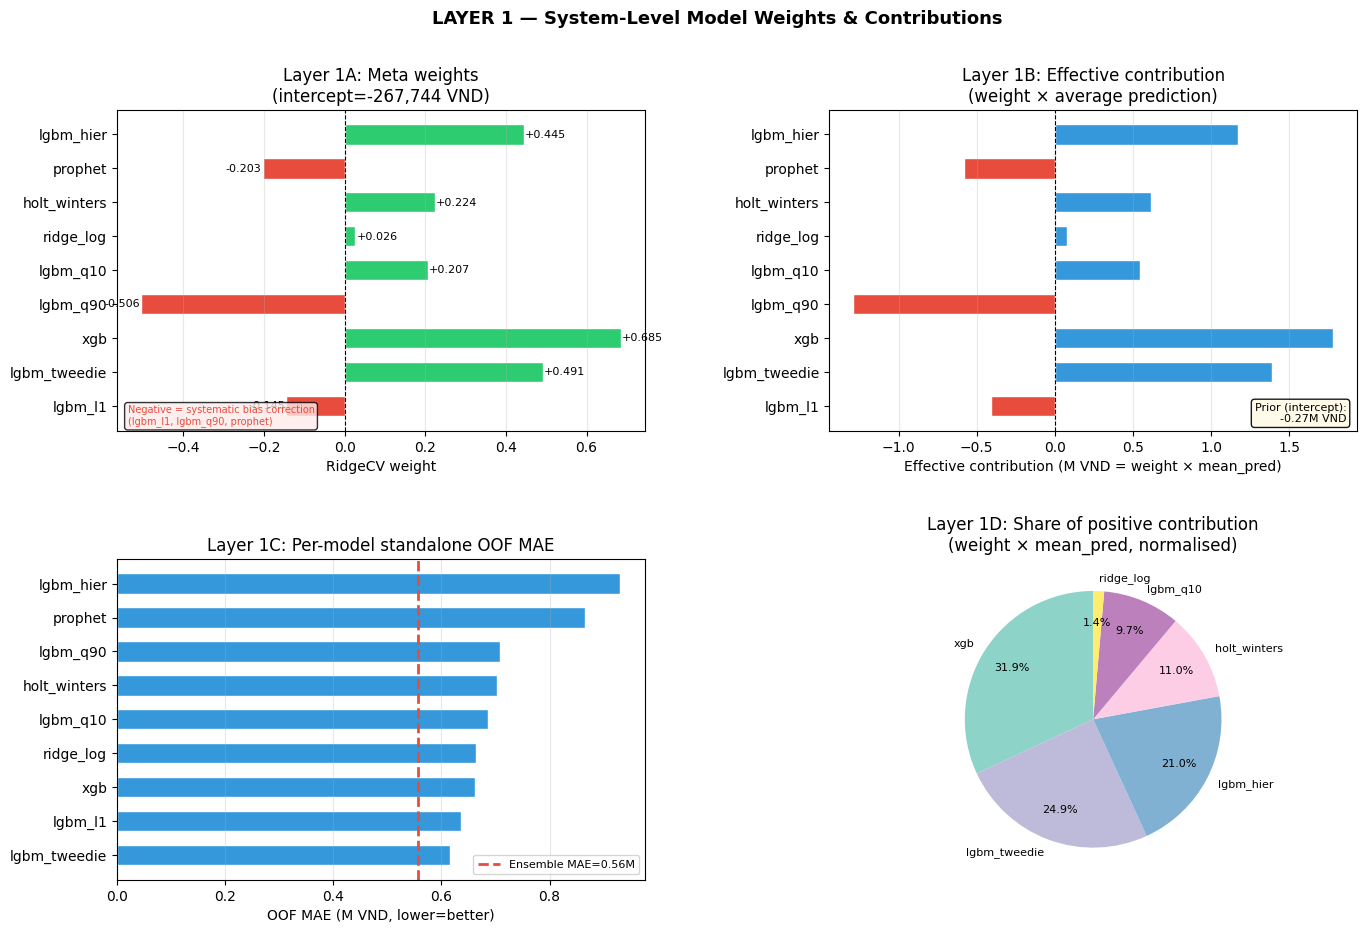

✓ Layer 1 plot saved
Computing weighted SHAP values ...
  Computing SHAP: lgbm_l1  (meta_coef=-0.1455, norm_w=0.059) ... done
  Computing SHAP: lgbm_tweedie  (meta_coef=+0.4914, norm_w=0.198) ... done
  Computing SHAP: xgb  (meta_coef=+0.6847, norm_w=0.276) ... done
  Computing SHAP: lgbm_q90  (meta_coef=-0.5055, norm_w=0.204) ... done
  Computing SHAP: lgbm_q10  (meta_coef=+0.2066, norm_w=0.083) ... done

  Baselines (E[f(X)]) per model:
    lgbm_l1        : 3014443.7476
    lgbm_tweedie   : 3016945.3216
    xgb            : 14.7765 [log scale]
    lgbm_q90       : 14.7765 [log scale]
    lgbm_q10       : 14.7753 [log scale]


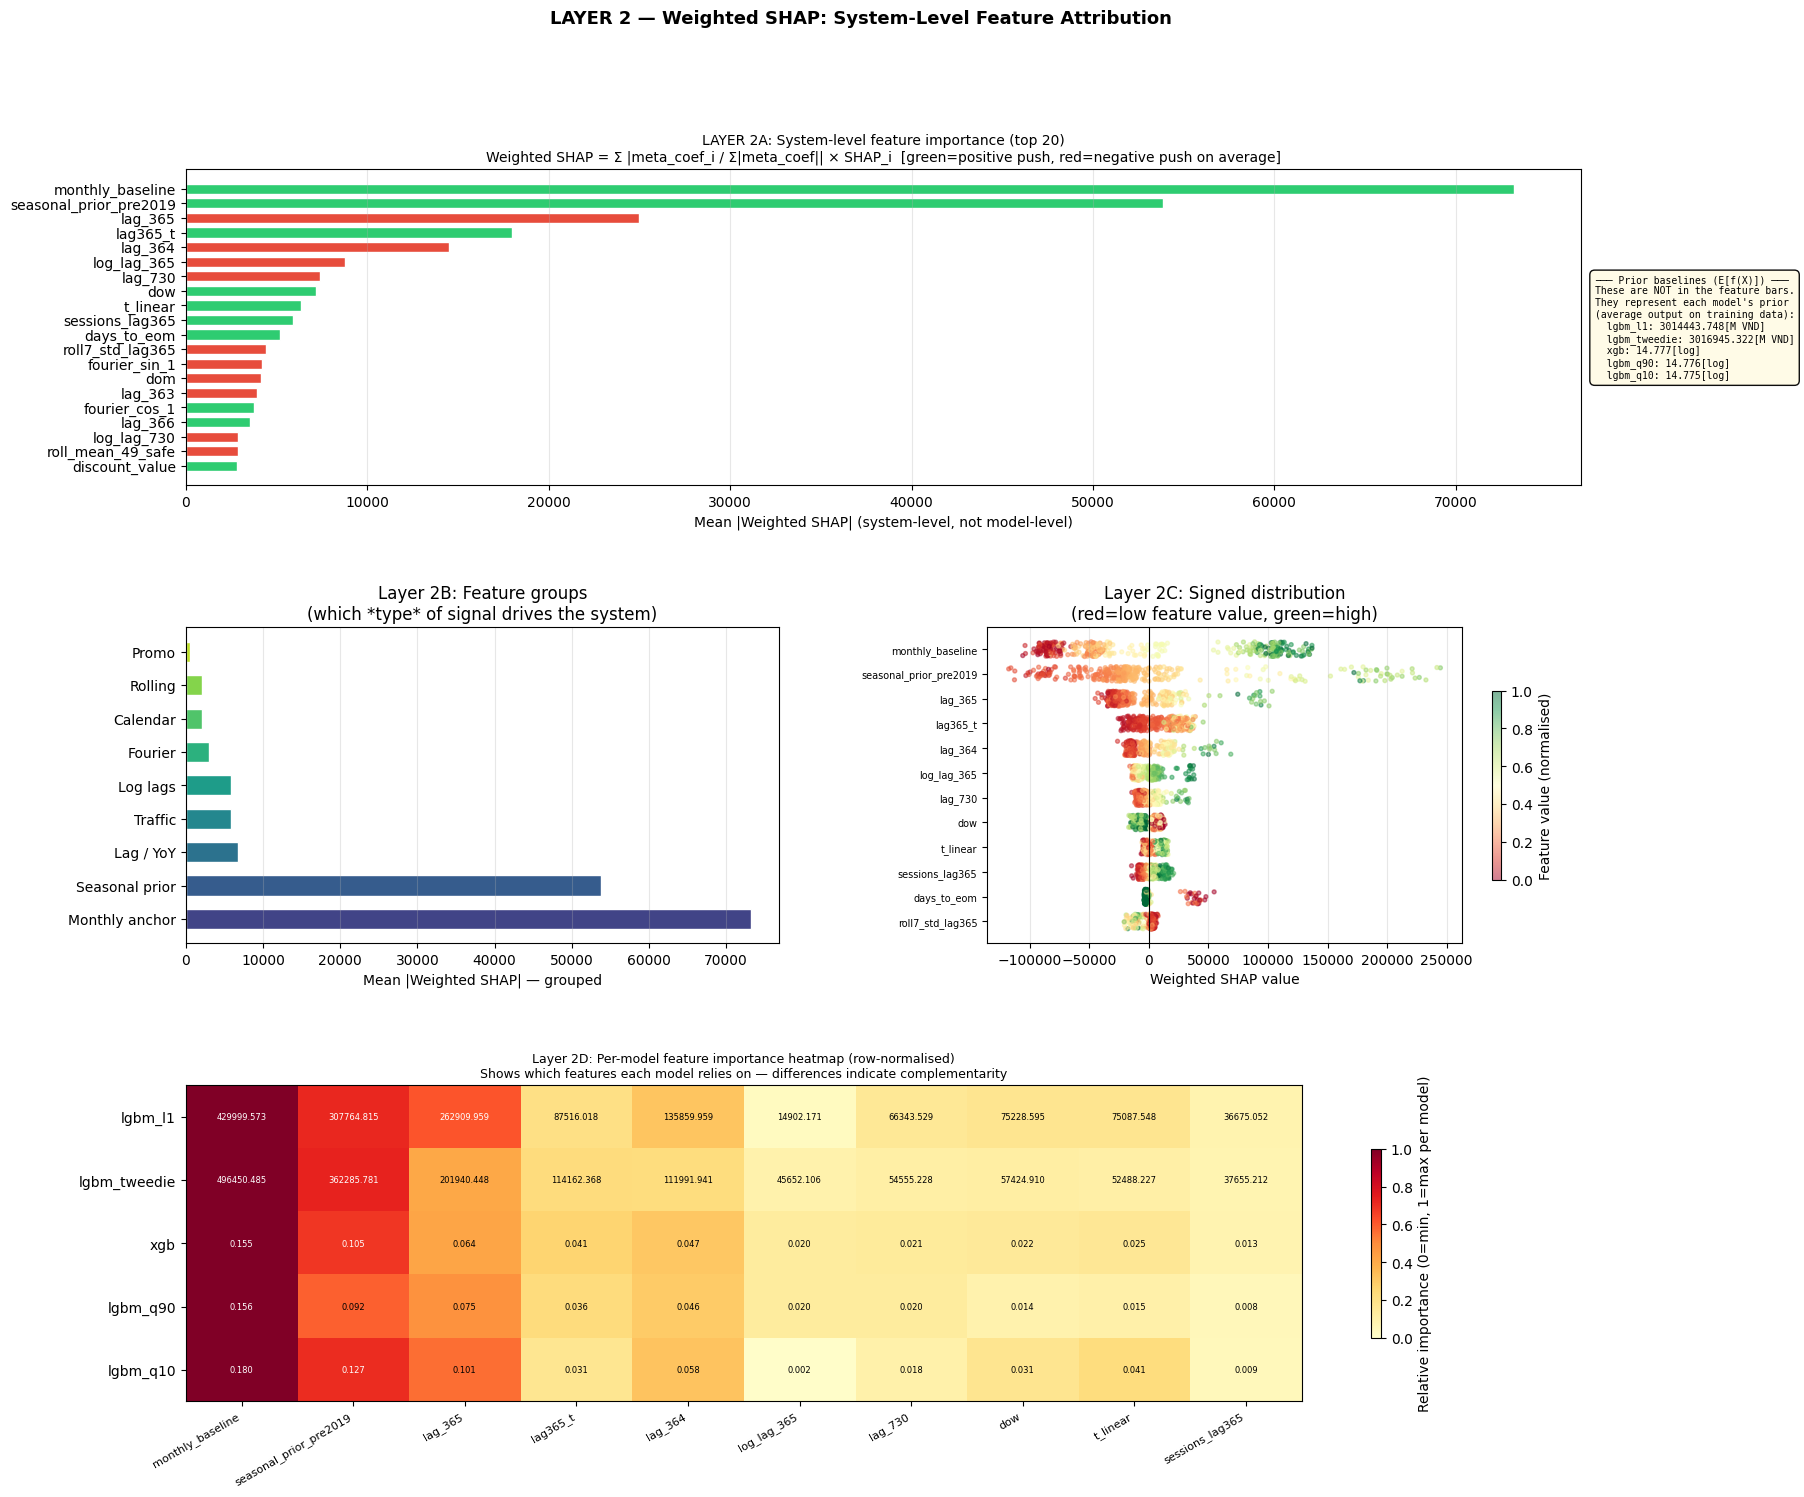

✓ Layer 2 plot saved


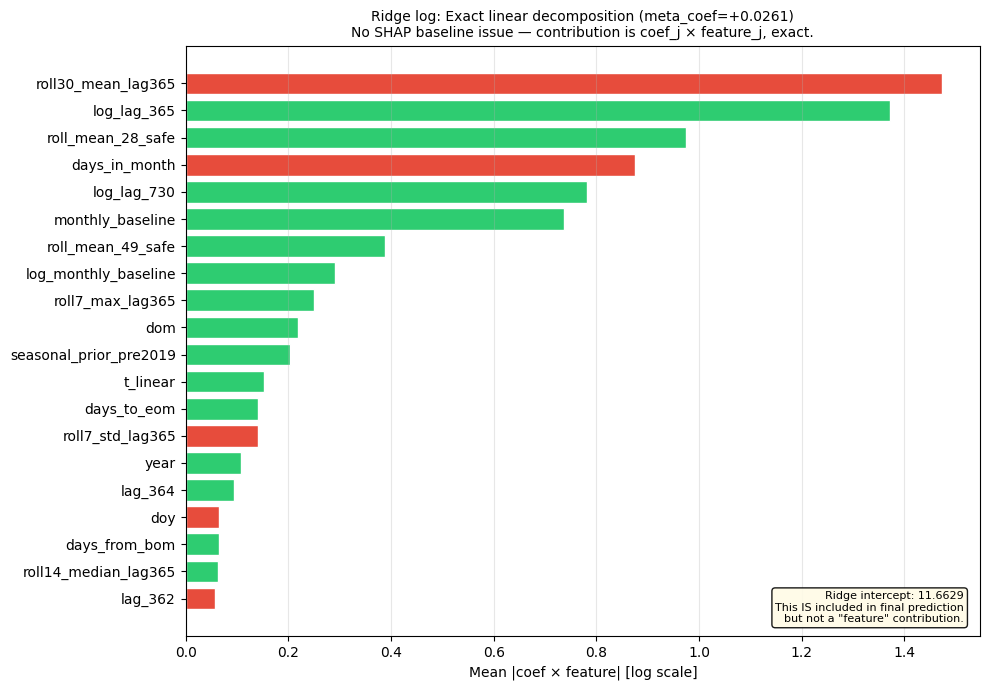

✓ Ridge decomp plot saved


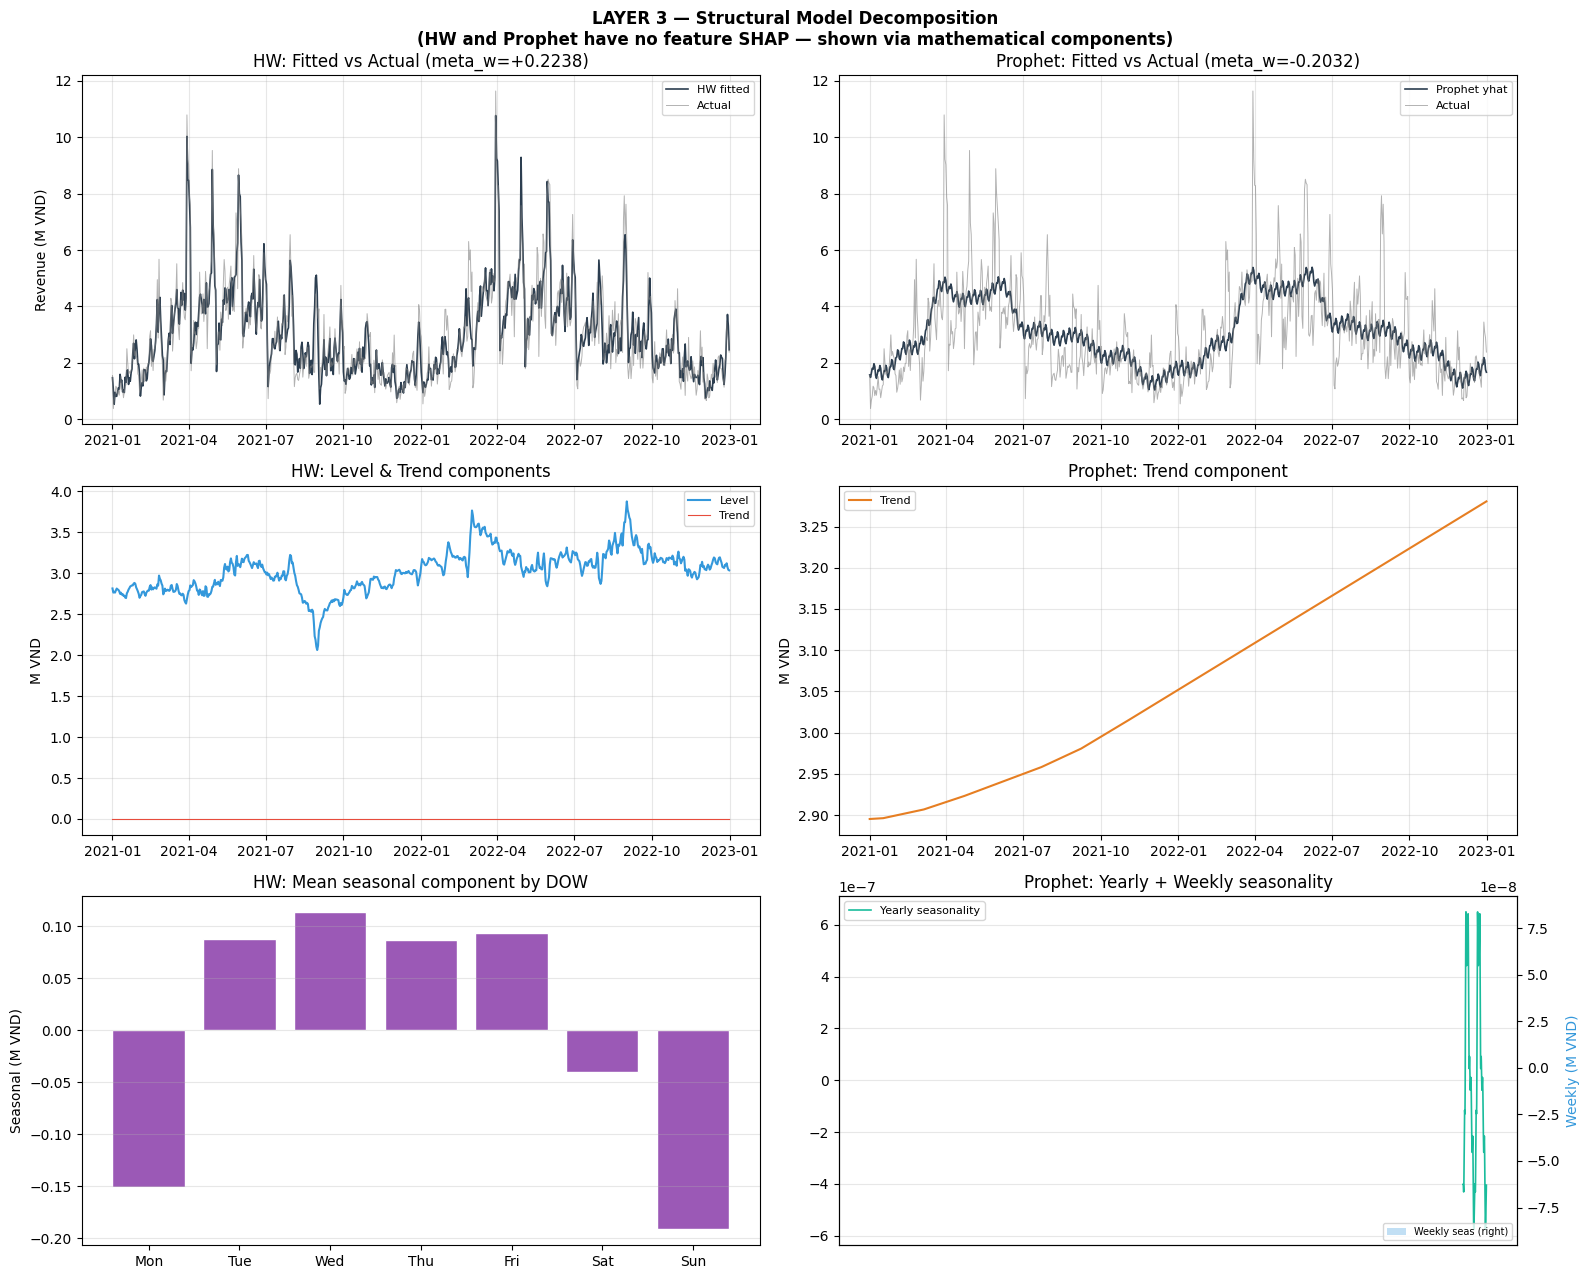

✓ Layer 3 structural plot saved

XAI INTERPRETATION GUIDE

How to read these plots without being misled by baseline dominance:

1. BASELINE (E[f(X)]) is NOT a bug — it is each model's prior (mean prediction
   on training data). For revenue (~3-4M VND/day), all SHAP values are deltas
   relative to this prior. Plots show it explicitly in the annotation box,
   NOT inside the feature bars.

2. WEIGHTED SHAP (Layer 2A/B/C) is the system-level view:
   - Positive bar = feature pushes ensemble prediction UP on average
   - Negative bar = feature pushes ensemble prediction DOWN on average
   - Weighting: tree models only, each model's SHAP scaled by |meta_coef|
   - Ridge: exact linear decomp (no SHAP needed, no baseline ambiguity)
   - HW / Prophet: shown as structural components (Layer 3), not SHAP

3. MODEL COMPLEMENTARITY (Layer 2D heatmap):
   - If two models have very different hot features, they are complementary
     and blending them correctly improves generalisation
   - If two mo

In [ ]:
# [32] Pre-Submit Checklist (auto)
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("PRE-SUBMIT CHECKLIST")
print("=" * 60)
checks = {
    'submission rows == 548'  : len(submission) == 548,
    'no NaN Revenue'          : submission['Revenue'].isna().sum() == 0,
    'no NaN COGS'             : submission['COGS'].isna().sum() == 0,
    'all Revenue >= 0'        : (submission['Revenue'] >= 0).all(),
    'all COGS >= 0'           : (submission['COGS'] >= 0).all(),
    'OOF valid rows >= 700'   : oof_frac_table.notna().sum() >= 700,
    'monthly_baseline no NaN' : df[df['is_train']]['monthly_baseline'].isna().sum() == 0,
    'meta weights printed'    : daily_meta is not None,
}
all_pass = True
for desc, result in checks.items():
    icon = '✓' if result else '✗'
    print(f"  [{icon}] {desc}")
    if not result:
        all_pass = False
print()
print("ALL CHECKS PASSED ✓" if all_pass else "⚠ SOME CHECKS FAILED — review above")


# =============================================================================
# PIPELINE v8 — XAI MODULE (thay thế cell [33] cũ)
# 3-layer explainability:
#   Layer 1 — System weights   : RidgeCV meta coefficients
#   Layer 2 — Weighted SHAP    : per tree-model SHAP × meta weight → aggregate
#   Layer 3 — Structural decomp: HW components + Prophet components
# =============================================================================
# ASSUMES: daily_meta, l2_models, oof_dict_scaled, df_train, MODEL_ORDER,
#          L2_FEATURES, hw_model, prophet_model, y_actual_oof, oof_mask in scope.

import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── Constants ─────────────────────────────────────────────────────────────────
XAI_SAMPLE_N   = 365          # rows for SHAP computation (1 OOF year = balanced)
XAI_TOP_FEATS  = 20           # top features in aggregated plot
TREE_MODELS    = ['lgbm_l1', 'lgbm_tweedie', 'xgb', 'lgbm_q90', 'lgbm_q10']
LINEAR_MODELS  = ['ridge_log']
STRUCT_MODELS  = ['holt_winters', 'prophet']
HIER_MODELS    = ['lgbm_hier'] if IMPROVEMENTS.get('lgbm_hier') else []

# ── Feature group labels (for grouped bar chart) ──────────────────────────────
FEATURE_GROUPS = {
    'Lag / YoY'   : ['lag_365', 'lag_364', 'lag_366', 'lag_730', 'lag365_t',
                      'yoy_ratio'] + [f'lag_{l}' for l in range(358, 373)],
    'Rolling'     : ['roll7_mean_lag365', 'roll7_median_lag365', 'roll7_std_lag365',
                     'roll7_max_lag365', 'roll14_median_lag365', 'roll30_mean_lag365',
                     'roll_mean_28_safe', 'roll_mean_49_safe'],
    'Monthly anchor': ['monthly_baseline', 'log_monthly_baseline'],
    'Calendar'    : ['dom', 'month', 'year', 'dow', 'is_weekend', 'doy',
                     'days_in_month', 'woy', 'is_bom', 'is_eom',
                     'days_to_eom', 'days_from_bom', 'eom_month', 'bom_month',
                     'dip_bom', 't_linear', 'is_post2019', 'is_odd_year'],
    'Fourier'     : ['fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2'],
    'Promo'       : ['is_promo', 'discount_value', 'promo_lift_score',
                     'days_since_promo_start', 'days_until_promo_end',
                     'stackable_flag', 'min_order_value', 'is_promo_month'],
    'Traffic'     : ['sessions_lag365'],
    'Seasonal prior': ['seasonal_prior_pre2019'],
    'Log lags'    : ['log_lag_365', 'log_lag_730'],
}


# =============================================================================
# LAYER 1 — System-level meta weights
# =============================================================================
def plot_layer1_system_weights(daily_meta, model_order, oof_dict_scaled,
                                y_actual_oof, oof_mask):
    """
    Panel A: RidgeCV coefficients (signed, with intercept shown separately).
    Panel B: Per-model OOF MAE — shows what each model contributes in terms of
             standalone accuracy, context for why weight is what it is.
    Panel C: Predicted vs actual scatter per model (OOF, colour = residual).
    """
    coefs = daily_meta.coef_
    intercept = float(daily_meta.intercept_)

    # ── Raw weight decomposition ───────────────────────────────────────────────
    # "Effective contribution" per model on OOF period = weight × mean(model_pred)
    oof_mask_arr = oof_mask.values
    model_means  = {k: np.nanmean(np.array(oof_dict_scaled[k])[oof_mask_arr])
                    for k in model_order}
    raw_contrib  = {k: coefs[i] * model_means[k]
                    for i, k in enumerate(model_order)}
    total_pos = sum(v for v in raw_contrib.values() if v > 0)

    # Normalised share (positive contributions only — easier to interpret)
    share = {k: max(v, 0) / total_pos if total_pos > 0 else 0
             for k, v in raw_contrib.items()}

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

    # ── Panel A: RidgeCV weights ───────────────────────────────────────────────
    ax_a = fig.add_subplot(gs[0, 0])
    colors_a = ['#2ecc71' if c >= 0 else '#e74c3c' for c in coefs]
    bars = ax_a.barh(model_order, coefs, color=colors_a, edgecolor='white', height=0.6)
    ax_a.axvline(0, color='black', lw=0.8, linestyle='--')
    ax_a.set_xlabel('RidgeCV weight')
    ax_a.set_title(f'Layer 1A: Meta weights\n(intercept={intercept:+,.0f} VND)')
    for bar, val in zip(bars, coefs):
        ax_a.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height() / 2,
                  f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    ax_a.grid(axis='x', alpha=0.3)
    # Annotate: negative weights are intentional corrections
    neg_models = [k for k, c in zip(model_order, coefs) if c < 0]
    if neg_models:
        ax_a.text(0.02, 0.02, f'Negative = systematic bias correction\n({", ".join(neg_models)})',
                  transform=ax_a.transAxes, fontsize=7, color='#e74c3c',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaea', alpha=0.8))

    # ── Panel B: Effective contribution (weight × mean_pred) ──────────────────
    ax_b = fig.add_subplot(gs[0, 1])
    contrib_vals = [raw_contrib[k] / 1e6 for k in model_order]
    colors_b = ['#3498db' if v >= 0 else '#e74c3c' for v in contrib_vals]
    ax_b.barh(model_order, contrib_vals, color=colors_b, edgecolor='white', height=0.6)
    ax_b.axvline(0, color='black', lw=0.8, linestyle='--')
    ax_b.set_xlabel('Effective contribution (M VND = weight × mean_pred)')
    ax_b.set_title('Layer 1B: Effective contribution\n(weight × average prediction)')
    ax_b.grid(axis='x', alpha=0.3)
    # Prior baseline annotation
    prior_val = (intercept + sum(raw_contrib.values())) / 1e6
    ax_b.text(0.98, 0.02, f'Prior (intercept):\n{intercept/1e6:+.2f}M VND',
              transform=ax_b.transAxes, fontsize=8, ha='right', va='bottom',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='#fffbe6', alpha=0.9))

    # ── Panel C: Per-model OOF MAE vs ensemble ────────────────────────────────
    ax_c = fig.add_subplot(gs[1, 0])
    maes = {}
    for name in model_order:
        arr = np.array(oof_dict_scaled[name])[oof_mask_arr]
        valid = ~np.isnan(arr) & ~np.isnan(y_actual_oof)
        maes[name] = mean_absolute_error(y_actual_oof[valid], arr[valid]) / 1e6

    # Ensemble MAE
    X_oof_m   = np.column_stack([oof_dict_scaled[k] for k in model_order])[oof_mask_arr]
    valid_e   = np.all(~np.isnan(X_oof_m), axis=1)
    ens_preds = np.clip(daily_meta.predict(X_oof_m[valid_e]), 0, None)
    ens_mae   = mean_absolute_error(y_actual_oof[valid_e], ens_preds) / 1e6

    names_sorted = sorted(maes, key=maes.get)
    vals_sorted  = [maes[k] for k in names_sorted]
    colors_c     = ['#2c3e50' if k != 'ensemble' else '#e74c3c' for k in names_sorted]

    ax_c.barh(names_sorted, vals_sorted, color='#3498db', edgecolor='white', height=0.6)
    ax_c.axvline(ens_mae, color='#e74c3c', lw=2, linestyle='--',
                 label=f'Ensemble MAE={ens_mae:.2f}M')
    ax_c.set_xlabel('OOF MAE (M VND, lower=better)')
    ax_c.set_title('Layer 1C: Per-model standalone OOF MAE')
    ax_c.legend(fontsize=8); ax_c.grid(axis='x', alpha=0.3)

    # ── Panel D: Share of positive contribution (pie) ─────────────────────────
    ax_d = fig.add_subplot(gs[1, 1])
    pos_models = [(k, share[k]) for k in model_order if share[k] > 0.001]
    pos_models.sort(key=lambda x: x[1], reverse=True)
    labels_pie = [k for k, _ in pos_models]
    sizes_pie  = [v for _, v in pos_models]
    cmap_pie   = plt.cm.Set3(np.linspace(0, 1, len(labels_pie)))
    wedges, texts, autotexts = ax_d.pie(
        sizes_pie, labels=labels_pie, autopct='%1.1f%%',
        colors=cmap_pie, startangle=90, pctdistance=0.75,
        textprops={'fontsize': 8})
    ax_d.set_title('Layer 1D: Share of positive contribution\n(weight × mean_pred, normalised)')

    plt.suptitle('LAYER 1 — System-Level Model Weights & Contributions',
                 fontsize=13, fontweight='bold')
    plt.savefig(DATA_DIR + 'xai_layer1_system_weights.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Layer 1 plot saved")

    return maes, raw_contrib


maes_per_model, raw_contrib = plot_layer1_system_weights(
    daily_meta, MODEL_ORDER, oof_dict_scaled, y_actual_oof, oof_mask)


# =============================================================================
# LAYER 2 — Weighted SHAP (tree models only)
# =============================================================================
def compute_weighted_shap(l2_models, daily_meta, model_order, df_train,
                           L2_FEATURES, oof_mask, n_sample=XAI_SAMPLE_N):
    """
    For each tree model:
      1. Compute SHAP values (TreeExplainer, fast exact)
      2. Weight by |meta_coef| / sum(|meta_coef_tree_models|)
      3. Sum weighted SHAP → system-level feature attribution

    Ridge handled separately via linear decomposition (coef × feature).
    HW / Prophet / lgbm_hier → structural layer (Layer 3).

    Returns:
      weighted_shap_matrix : (n_sample, n_features) — weighted sum of SHAP
      baseline_dict        : {model_name: E[f(X)]}  — each model's prior
      shap_per_model       : {model_name: shap_values array}
      X_sample             : the sampled feature rows
    """
    coefs       = daily_meta.coef_
    tree_idx    = {k: i for i, k in enumerate(model_order) if k in TREE_MODELS + HIER_MODELS}
    coef_abs_sum = sum(abs(coefs[i]) for i in tree_idx.values())

    # Sample from OOF period
    oof_rows  = df_train[oof_mask].reset_index(drop=True)
    n_sample  = min(n_sample, len(oof_rows))
    rng       = np.random.default_rng(RANDOM_SEED)
    sample_idx = rng.choice(len(oof_rows), size=n_sample, replace=False)
    X_sample  = oof_rows.iloc[sample_idx][L2_FEATURES].reset_index(drop=True)

    weighted_shap_matrix = np.zeros((n_sample, len(L2_FEATURES)))
    shap_per_model = {}
    baseline_dict  = {}

    for name, model in l2_models.items():
        if name not in tree_idx:
            continue

        meta_w = coefs[tree_idx[name]]
        norm_w = (abs(meta_w) / coef_abs_sum) if coef_abs_sum > 0 else 0.0

        print(f"  Computing SHAP: {name}  (meta_coef={meta_w:+.4f}, norm_w={norm_w:.3f}) ...",
              end=' ', flush=True)

        explainer = shap.TreeExplainer(model)
        sv        = explainer.shap_values(X_sample)  # (n_sample, n_features)

        # For log-scale models, SHAP is in log space — we note this but still
        # weight in log space since the baseline is also log-space.
        # For comparison across models, normalise SHAP by model's OOF std.
        shap_per_model[name] = sv
        baseline_dict[name]  = float(explainer.expected_value)

        # Sign of weight carries direction (negative weight = correction)
        sign = np.sign(meta_w) if meta_w != 0 else 1.0
        weighted_shap_matrix += norm_w * sign * sv

        print("done")

    print(f"\n  Baselines (E[f(X)]) per model:")
    for name, bv in baseline_dict.items():
        log_flag = ' [log scale]' if name in LOG_SCALE_MODELS_NO_BIAS + LOG_SCALE_MODELS_WITH_BIAS else ''
        print(f"    {name:15s}: {bv:.4f}{log_flag}")

    return weighted_shap_matrix, baseline_dict, shap_per_model, X_sample


print("Computing weighted SHAP values ...")
weighted_shap, baseline_dict, shap_per_model, X_sample = compute_weighted_shap(
    l2_models, daily_meta, MODEL_ORDER, df_train, L2_FEATURES, oof_mask)


def plot_layer2_weighted_shap(weighted_shap, shap_per_model, baseline_dict,
                               X_sample, L2_FEATURES, daily_meta, model_order,
                               n_top=XAI_TOP_FEATS):
    """
    Panel A: Aggregated weighted SHAP bar (mean |weighted_SHAP|).
    Panel B: Grouped bar — contribution by feature group.
    Panel C: Beeswarm for top features (signed, shows direction).
    Panel D: Per-model SHAP heatmap (top 10 features × all tree models).
    Annotation: Baseline prior shown explicitly, NOT inside the feature bars.
    """
    feat_names = L2_FEATURES
    mean_abs   = np.abs(weighted_shap).mean(axis=0)
    top_idx    = np.argsort(mean_abs)[::-1][:n_top]
    top_feats  = [feat_names[i] for i in top_idx]
    top_vals   = mean_abs[top_idx]

    fig = plt.figure(figsize=(18, 16))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel A: Top features weighted SHAP ───────────────────────────────────
    ax_a = fig.add_subplot(gs[0, :])   # full width

    # Direction: mean signed SHAP (positive = pushes prediction up)
    mean_signed = weighted_shap[:, top_idx].mean(axis=0)
    bar_colors  = ['#2ecc71' if v >= 0 else '#e74c3c' for v in mean_signed]

    ax_a.barh(top_feats[::-1], top_vals[::-1], color=bar_colors[::-1],
              edgecolor='white', height=0.7)
    ax_a.set_xlabel('Mean |Weighted SHAP| (system-level, not model-level)')
    ax_a.set_title(
        f'LAYER 2A: System-level feature importance (top {n_top})\n'
        f'Weighted SHAP = Σ |meta_coef_i / Σ|meta_coef|| × SHAP_i  '
        f'[green=positive push, red=negative push on average]',
        fontsize=10)
    ax_a.grid(axis='x', alpha=0.3)

    # Baseline annotation box (separate from bars — explicit)
    baseline_note = '\n'.join([
        '─── Prior baselines (E[f(X)]) ───',
        'These are NOT in the feature bars.',
        'They represent each model\'s prior',
        '(average output on training data):',
    ] + [f'  {k}: {v:.3f}{"[log]" if k in LOG_SCALE_MODELS_NO_BIAS+LOG_SCALE_MODELS_WITH_BIAS else "[M VND]"}'
         for k, v in baseline_dict.items()])
    ax_a.text(1.01, 0.5, baseline_note, transform=ax_a.transAxes,
              fontsize=7, va='center', family='monospace',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='#fffbe6', alpha=0.95))

    # ── Panel B: Feature groups ────────────────────────────────────────────────
    ax_b = fig.add_subplot(gs[1, 0])
    group_scores = {}
    for group, feats in FEATURE_GROUPS.items():
        idxs = [feat_names.index(f) for f in feats if f in feat_names]
        if idxs:
            group_scores[group] = float(np.abs(weighted_shap[:, idxs]).mean())

    groups_sorted = sorted(group_scores, key=group_scores.get, reverse=True)
    vals_sorted   = [group_scores[g] for g in groups_sorted]
    cmap_g = plt.cm.viridis(np.linspace(0.2, 0.9, len(groups_sorted)))
    ax_b.barh(groups_sorted, vals_sorted, color=cmap_g, edgecolor='white', height=0.6)
    ax_b.set_xlabel('Mean |Weighted SHAP| — grouped')
    ax_b.set_title('Layer 2B: Feature groups\n(which *type* of signal drives the system)')
    ax_b.grid(axis='x', alpha=0.3)

    # ── Panel C: Beeswarm / scatter for top 12 features ───────────────────────
    ax_c = fig.add_subplot(gs[1, 1])
    top12 = min(12, n_top)
    top12_feats = top_feats[:top12]
    top12_idx   = [feat_names.index(f) for f in top12_feats]

    # Normalise feature values to [0,1] per feature for colour
    X_norm = X_sample[top12_feats].values.astype(float)
    X_norm_scaled = np.zeros_like(X_norm)
    for j in range(X_norm.shape[1]):
        col = X_norm[:, j]
        mn, mx = np.nanmin(col), np.nanmax(col)
        if mx > mn:
            X_norm_scaled[:, j] = (col - mn) / (mx - mn)
        else:
            X_norm_scaled[:, j] = 0.5

    for j, feat in enumerate(top12_feats[::-1]):
        orig_j = top12_feats.index(feat)
        shap_col = weighted_shap[:, feat_names.index(feat)]
        y_jitter = np.random.default_rng(j).uniform(-0.3, 0.3, len(shap_col))
        sc = ax_c.scatter(shap_col, np.full(len(shap_col), j) + y_jitter,
                          c=X_norm_scaled[:, orig_j], cmap='RdYlGn',
                          s=8, alpha=0.5, vmin=0, vmax=1)

    ax_c.set_yticks(range(top12))
    ax_c.set_yticklabels(top12_feats[::-1], fontsize=7)
    ax_c.axvline(0, color='black', lw=0.8)
    ax_c.set_xlabel('Weighted SHAP value')
    ax_c.set_title('Layer 2C: Signed distribution\n(red=low feature value, green=high)')
    plt.colorbar(sc, ax=ax_c, label='Feature value (normalised)', shrink=0.6)
    ax_c.grid(axis='x', alpha=0.3)

    # ── Panel D: Per-model top-10 SHAP heatmap ────────────────────────────────
    ax_d = fig.add_subplot(gs[2, :])
    top10_feats = top_feats[:10]
    top10_idx   = [feat_names.index(f) for f in top10_feats]

    heat_data = np.zeros((len(shap_per_model), 10))
    model_names_heat = list(shap_per_model.keys())
    for i, name in enumerate(model_names_heat):
        sv = shap_per_model[name]
        heat_data[i, :] = np.abs(sv[:, top10_idx]).mean(axis=0)

    # Normalise each model row by its own max so all models comparable
    row_max = heat_data.max(axis=1, keepdims=True)
    heat_norm = np.divide(heat_data, row_max, where=row_max > 0)

    im = ax_d.imshow(heat_norm, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax_d.set_xticks(range(10)); ax_d.set_xticklabels(top10_feats, rotation=30, ha='right', fontsize=8)
    ax_d.set_yticks(range(len(model_names_heat))); ax_d.set_yticklabels(model_names_heat)
    ax_d.set_title(
        'Layer 2D: Per-model feature importance heatmap (row-normalised)\n'
        'Shows which features each model relies on — differences indicate complementarity',
        fontsize=9)
    plt.colorbar(im, ax=ax_d, label='Relative importance (0=min, 1=max per model)', shrink=0.6)

    # Annotate cells with raw values
    for i in range(len(model_names_heat)):
        for j in range(10):
            ax_d.text(j, i, f'{heat_data[i,j]:.3f}', ha='center', va='center',
                      fontsize=6, color='black' if heat_norm[i,j] < 0.6 else 'white')

    plt.suptitle('LAYER 2 — Weighted SHAP: System-Level Feature Attribution',
                 fontsize=13, fontweight='bold')
    plt.savefig(DATA_DIR + 'xai_layer2_weighted_shap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Layer 2 plot saved")


plot_layer2_weighted_shap(
    weighted_shap, shap_per_model, baseline_dict,
    X_sample, L2_FEATURES, daily_meta, MODEL_ORDER)


# Ridge linear decomposition (separate — not SHAP, but exact)
def plot_ridge_linear_decomp(l2_models, df_train, RIDGE_LOG_FEATURES, oof_mask,
                              daily_meta, model_order):
    """
    Ridge is linear: contribution_j = coef_j × feature_j.
    We compute mean absolute contribution per feature over OOF period.
    This is exact (not approximated) — no baseline ambiguity.
    """
    ridge = l2_models['ridge_log']
    X_oof_rl = df_train.loc[oof_mask, RIDGE_LOG_FEATURES].fillna(0)

    ridge_meta_w = daily_meta.coef_[model_order.index('ridge_log')]
    # Contribution per feature per row (in log space)
    contributions = X_oof_rl.values * ridge.coef_  # (n, p)
    mean_abs_contrib = np.abs(contributions).mean(axis=0)

    # Sort and show top 20
    top_n = 20
    top_idx = np.argsort(mean_abs_contrib)[::-1][:top_n]
    top_feats = [RIDGE_LOG_FEATURES[i] for i in top_idx]
    top_vals  = mean_abs_contrib[top_idx]
    mean_sign = contributions[:, top_idx].mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in mean_sign]
    ax.barh(top_feats[::-1], top_vals[::-1], color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Mean |coef × feature| [log scale]')
    ax.set_title(
        f'Ridge log: Exact linear decomposition (meta_coef={ridge_meta_w:+.4f})\n'
        f'No SHAP baseline issue — contribution is coef_j × feature_j, exact.',
        fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.text(0.98, 0.02,
            f'Ridge intercept: {ridge.intercept_:.4f}\n'
            f'This IS included in final prediction\nbut not a "feature" contribution.',
            transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fffbe6', alpha=0.9))
    plt.tight_layout()
    plt.savefig(DATA_DIR + 'xai_ridge_decomp.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Ridge decomp plot saved")


plot_ridge_linear_decomp(
    l2_models, df_train, RIDGE_LOG_FEATURES, oof_mask, daily_meta, MODEL_ORDER)


# =============================================================================
# LAYER 3 — Structural decomposition (HW + Prophet)
# =============================================================================
def plot_layer3_structural_decomp(hw_model, prophet_model, df_train, oof_mask,
                                   daily_meta, model_order):
    """
    HW and Prophet can't produce feature-level SHAP — but they have explicit
    mathematical decompositions that are interpretable on their own:

    HW decomposition:  forecast(t) = level(t) + trend(t) + seasonal(t)
    Prophet decomp:    yhat(t)    = trend(t) + yearly(t) + weekly(t)

    We plot these components and annotate with their meta-learner weight so
    the analyst understands how much these structural signals contribute.
    """
    hw_meta_w      = daily_meta.coef_[model_order.index('holt_winters')]
    prophet_meta_w = daily_meta.coef_[model_order.index('prophet')]

    oof_dates = pd.DatetimeIndex(df_train.loc[oof_mask, 'Date'].values)

    fig, axes = plt.subplots(3, 2, figsize=(16, 13))
    fig.suptitle(
        'LAYER 3 — Structural Model Decomposition\n'
        '(HW and Prophet have no feature SHAP — shown via mathematical components)',
        fontsize=12, fontweight='bold')

    # ── Panel A/B: HW components ──────────────────────────────────────────────
    try:
        hw_filt   = hw_model.fittedvalues
        hw_level  = hw_model.level
        hw_trend  = hw_model.trend
        hw_season = hw_model.season

        # Align to OOF period
        hw_level_oof  = hw_level.reindex(oof_dates)
        hw_trend_oof  = hw_trend.reindex(oof_dates)
        hw_season_oof = hw_season.reindex(oof_dates)
        hw_fitted_oof = hw_filt.reindex(oof_dates)

        axes[0, 0].plot(oof_dates, hw_fitted_oof / 1e6, color='#2c3e50', lw=1.2, label='HW fitted')
        actual_rev = df_train.loc[oof_mask, 'Revenue'].values
        axes[0, 0].plot(oof_dates, actual_rev / 1e6, color='gray', lw=0.7, alpha=0.6, label='Actual')
        axes[0, 0].set_title(f'HW: Fitted vs Actual (meta_w={hw_meta_w:+.4f})')
        axes[0, 0].legend(fontsize=8); axes[0, 0].grid(alpha=0.3)
        axes[0, 0].set_ylabel('Revenue (M VND)')

        axes[1, 0].plot(oof_dates, hw_level_oof / 1e6, color='#3498db', label='Level')
        axes[1, 0].plot(oof_dates, hw_trend_oof / 1e6, color='#e74c3c', lw=0.8, label='Trend')
        axes[1, 0].set_title('HW: Level & Trend components'); axes[1, 0].legend(fontsize=8)
        axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylabel('M VND')

        # Weekly seasonal pattern (extract from seasonal component)
        hw_seas_7 = hw_season_oof.groupby(oof_dates.dayofweek).mean()
        dows = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        axes[2, 0].bar(range(7), hw_seas_7.values / 1e6,
                       color='#9b59b6', edgecolor='white')
        axes[2, 0].set_xticks(range(7)); axes[2, 0].set_xticklabels(dows)
        axes[2, 0].set_title('HW: Mean seasonal component by DOW')
        axes[2, 0].set_ylabel('Seasonal (M VND)'); axes[2, 0].grid(axis='y', alpha=0.3)

    except Exception as e:
        for row in range(3):
            axes[row, 0].text(0.5, 0.5, f'HW decomp unavailable:\n{e}',
                              ha='center', va='center', transform=axes[row, 0].transAxes)
        print(f"  HW decomp failed: {e}")

    # ── Panel D/E/F: Prophet components ──────────────────────────────────────
    try:
        ph_future = prophet_model.make_future_dataframe(
            periods=(pd.Timestamp('2022-12-31') -
                     pd.Timestamp(df_train['Date'].min())).days, freq='D')
        ph_fc = prophet_model.predict(ph_future)
        ph_fc = ph_fc.set_index('ds')
        ph_oof = ph_fc.reindex(oof_dates)

        axes[0, 1].plot(oof_dates, ph_oof['yhat'] / 1e6, color='#2c3e50', lw=1.2, label='Prophet yhat')
        axes[0, 1].plot(oof_dates, actual_rev / 1e6, color='gray', lw=0.7, alpha=0.6, label='Actual')
        axes[0, 1].set_title(f'Prophet: Fitted vs Actual (meta_w={prophet_meta_w:+.4f})')
        axes[0, 1].legend(fontsize=8); axes[0, 1].grid(alpha=0.3)

        axes[1, 1].plot(oof_dates, ph_oof['trend'] / 1e6, color='#e67e22', lw=1.5, label='Trend')
        axes[1, 1].set_title('Prophet: Trend component'); axes[1, 1].legend(fontsize=8)
        axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylabel('M VND')

        # Yearly seasonality (over OOF dates)
        if 'yearly' in ph_oof.columns:
            axes[2, 1].plot(oof_dates, ph_oof['yearly'] / 1e6,
                            color='#1abc9c', lw=1.2, label='Yearly seasonality')
        if 'weekly' in ph_oof.columns:
            weekly_mean = ph_oof['weekly'].groupby(pd.DatetimeIndex(oof_dates).dayofweek).mean()
            ax_tw = axes[2, 1].twinx()
            ax_tw.bar(range(7), weekly_mean.values / 1e6,
                      color='#3498db', alpha=0.3, label='Weekly seas (right)')
            ax_tw.set_ylabel('Weekly (M VND)', color='#3498db')
            ax_tw.legend(loc='lower right', fontsize=7)
        axes[2, 1].set_xticks([])
        axes[2, 1].set_title('Prophet: Yearly + Weekly seasonality')
        axes[2, 1].legend(loc='upper left', fontsize=8)
        axes[2, 1].grid(alpha=0.3)

    except Exception as e:
        for row in range(3):
            axes[row, 1].text(0.5, 0.5, f'Prophet decomp unavailable:\n{e}',
                              ha='center', va='center', transform=axes[row, 1].transAxes)
        print(f"  Prophet decomp failed: {e}")

    plt.tight_layout()
    plt.savefig(DATA_DIR + 'xai_layer3_structural.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Layer 3 structural plot saved")


plot_layer3_structural_decomp(
    hw_model, prophet_model, df_train, oof_mask, daily_meta, MODEL_ORDER)


# =============================================================================
# SUMMARY: Interpretation Guide (auto-printed)
# =============================================================================
print()
print("=" * 70)
print("XAI INTERPRETATION GUIDE")
print("=" * 70)
print("""
How to read these plots without being misled by baseline dominance:

1. BASELINE (E[f(X)]) is NOT a bug — it is each model's prior (mean prediction
   on training data). For revenue (~3-4M VND/day), all SHAP values are deltas
   relative to this prior. Plots show it explicitly in the annotation box,
   NOT inside the feature bars.

2. WEIGHTED SHAP (Layer 2A/B/C) is the system-level view:
   - Positive bar = feature pushes ensemble prediction UP on average
   - Negative bar = feature pushes ensemble prediction DOWN on average
   - Weighting: tree models only, each model's SHAP scaled by |meta_coef|
   - Ridge: exact linear decomp (no SHAP needed, no baseline ambiguity)
   - HW / Prophet: shown as structural components (Layer 3), not SHAP

3. MODEL COMPLEMENTARITY (Layer 2D heatmap):
   - If two models have very different hot features, they are complementary
     and blending them correctly improves generalisation
   - If two models are nearly identical in the heatmap, one may be redundant

4. STRUCTURAL MODELS (Layer 3):
   - HW weight tells you how much the pure time-series momentum matters
   - Prophet weight tells you how much calendar/trend structure matters
   - Their components (trend, seasonality) are interpretable mathematically
   - Negative meta_weight for HW/Prophet = the model consistently overshoots,
     so the ensemble corrects by subtracting a fraction of its prediction

5. RIDGE contribution:
   - If ridge_log has a large meta_weight, it means log-linear relationships
     (multiplicative seasonality × trend) dominate the signal
   - Its intercept is NOT a feature — it represents the log-scale prior
""")

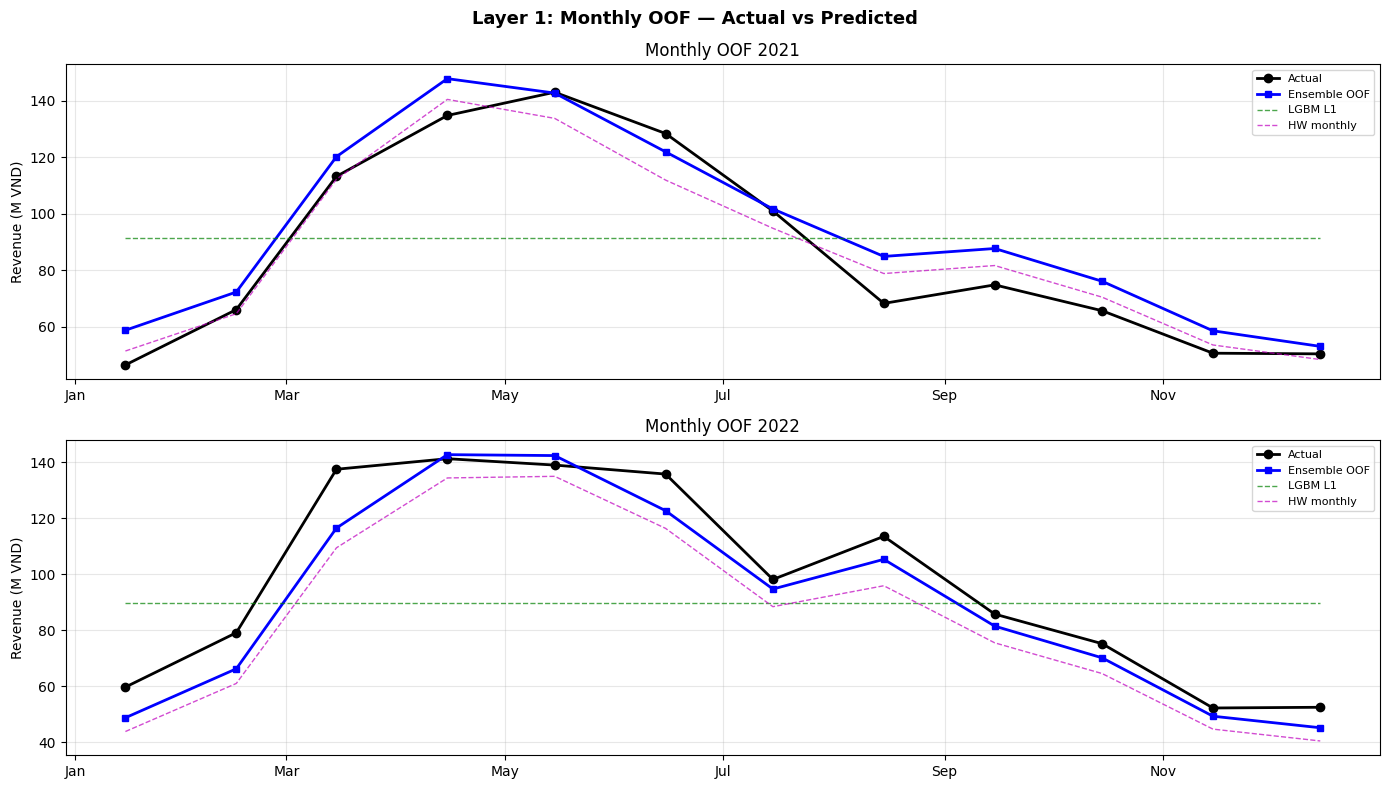

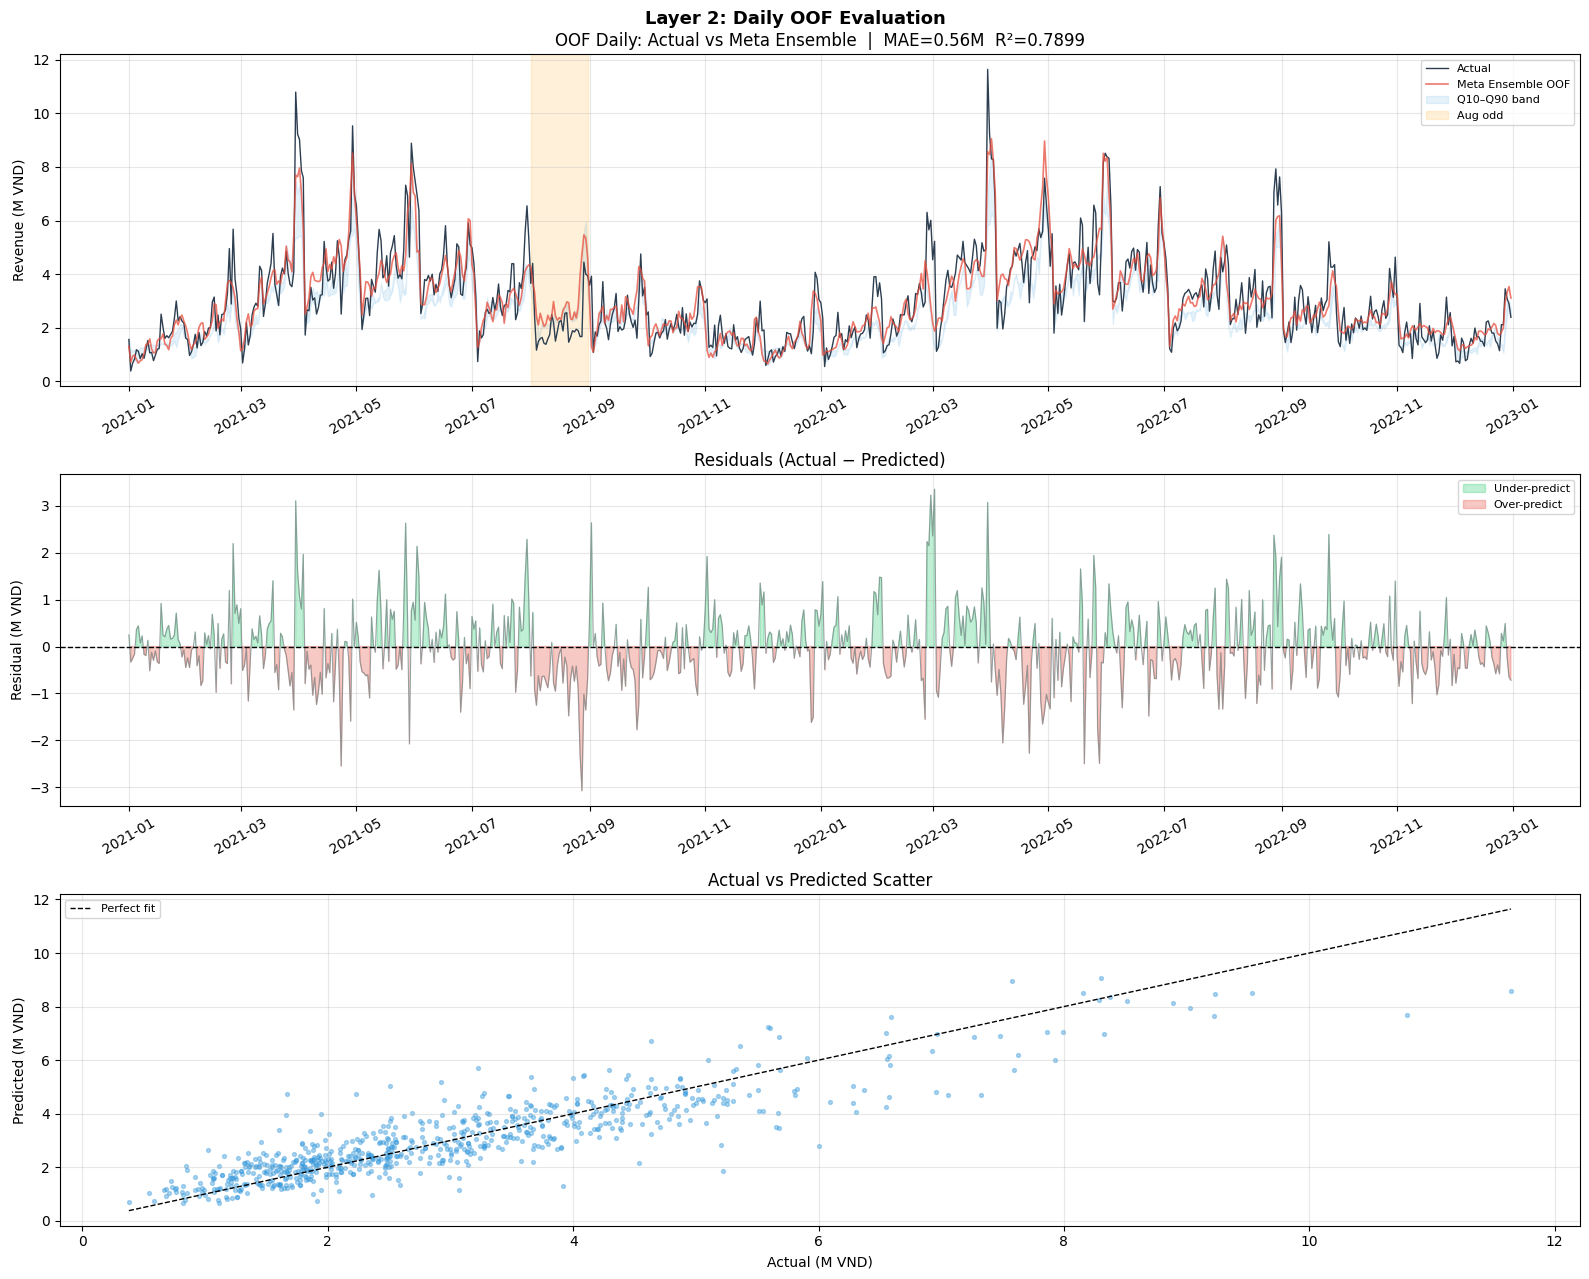

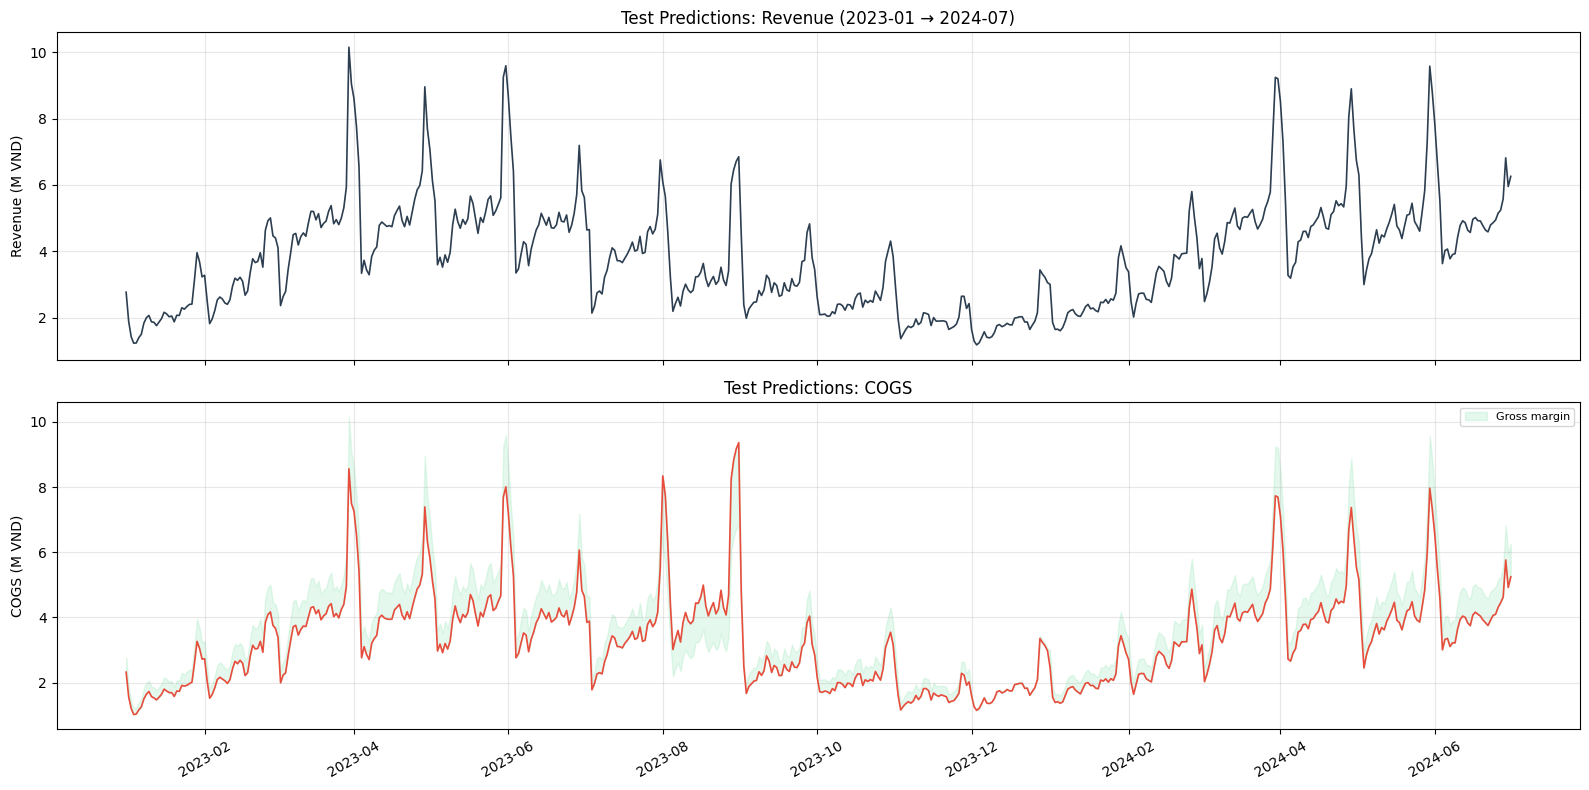

In [ ]:
# [34] Eval Plots
# -----------------------------------------------------------------------------
# ── Plot 1: Monthly L1 OOF ───────────────────────────────────────────────────
_actual_monthly_hist_ev = (sales
    .assign(ym=lambda x: x['Date'].dt.to_period('M'))
    .groupby('ym')['Revenue'].sum().to_dict())

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, yr in zip(axes, [2021, 2022]):
    periods = sorted([ym for ym in l1_oof_monthly if ym.year == yr])
    dates_  = [p.to_timestamp() + pd.Timedelta(days=14) for p in periods]
    actual_ = [_actual_monthly_hist_ev.get(p, np.nan) / 1e6 for p in periods]
    pred_   = [l1_oof_monthly.get(p, np.nan) / 1e6 for p in periods]
    lgbm_p_ = [monthly_oof_dict['lgbm_l1'].get(p, np.nan) / 1e6 for p in periods]
    hw_p_   = [monthly_oof_dict['hw_monthly'].get(p, np.nan) / 1e6 for p in periods]

    ax.plot(dates_, actual_, 'k-o', lw=2, ms=6, label='Actual')
    ax.plot(dates_, pred_,   'b-s', lw=2, ms=5, label='Ensemble OOF')
    ax.plot(dates_, lgbm_p_, 'g--', lw=1, alpha=0.7, label='LGBM L1')
    ax.plot(dates_, hw_p_,   'm--', lw=1, alpha=0.7, label='HW monthly')
    ax.set_ylabel('Revenue (M VND)')
    ax.set_title(f'Monthly OOF {yr}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.suptitle('Layer 1: Monthly OOF — Actual vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# ── Plot 2: Daily L2 OOF — 3 panels ─────────────────────────────────────────
oof_date_series = pd.to_datetime(df_train.loc[oof_mask, 'Date'].values)
X_oof_meta      = np.column_stack([oof_dict_scaled[k] for k in MODEL_ORDER])[oof_mask.values]
valid_meta_p    = np.all(~np.isnan(X_oof_meta), axis=1)
ens_oof_p       = np.full(oof_mask.sum(), np.nan)
ens_oof_p[valid_meta_p] = np.clip(daily_meta.predict(X_oof_meta[valid_meta_p]), 0, None)
y_oof_p         = y_actual_oof

fig, axes = plt.subplots(3, 1, figsize=(16, 13))

# Panel A — Time series
ax = axes[0]
ax.plot(oof_date_series, y_oof_p / 1e6,    color='#2c3e50', lw=1.0, label='Actual')
ax.plot(oof_date_series, ens_oof_p / 1e6,  color='#e74c3c', lw=1.2, alpha=0.75,
        label='Meta Ensemble OOF')
ax.fill_between(oof_date_series,
                np.array(oof_dict_scaled['lgbm_q10'])[oof_mask.values] / 1e6,
                np.array(oof_dict_scaled['lgbm_q90'])[oof_mask.values] / 1e6,
                alpha=0.12, color='#3498db', label='Q10–Q90 band')
for yr_s in [2021]:
    ax.axvspan(pd.Timestamp(f'{yr_s}-08-01'), pd.Timestamp(f'{yr_s}-08-31'),
               color='orange', alpha=0.15, label='Aug odd')
ax.set_ylabel('Revenue (M VND)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
valid_m   = ~np.isnan(ens_oof_p)
_mae_ens  = mean_absolute_error(y_oof_p[valid_m], ens_oof_p[valid_m])
_r2_ens   = r2_score(y_oof_p[valid_m], ens_oof_p[valid_m])
ax.set_title(f'OOF Daily: Actual vs Meta Ensemble  |  MAE={_mae_ens/1e6:.2f}M  R²={_r2_ens:.4f}')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel B — Residuals
ax = axes[1]
resid = y_oof_p - ens_oof_p
ax.plot(oof_date_series, resid / 1e6, color='#7f8c8d', lw=0.8, alpha=0.8)
ax.axhline(0, color='black', lw=1.0, linestyle='--')
ax.fill_between(oof_date_series, resid / 1e6, 0,
                where=(resid > 0), color='#2ecc71', alpha=0.3, label='Under-predict')
ax.fill_between(oof_date_series, resid / 1e6, 0,
                where=(resid < 0), color='#e74c3c', alpha=0.3, label='Over-predict')
ax.set_ylabel('Residual (M VND)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Residuals (Actual − Predicted)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Panel C — Scatter
ax = axes[2]
valid_sc = ~np.isnan(ens_oof_p)
ax.scatter(y_oof_p[valid_sc] / 1e6, ens_oof_p[valid_sc] / 1e6,
           s=8, alpha=0.4, color='#3498db')
lim_lo = min(y_oof_p[valid_sc].min(), ens_oof_p[valid_sc].min()) / 1e6
lim_hi = max(y_oof_p[valid_sc].max(), ens_oof_p[valid_sc].max()) / 1e6
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, label='Perfect fit')
ax.set_xlabel('Actual (M VND)'); ax.set_ylabel('Predicted (M VND)')
ax.set_title('Actual vs Predicted Scatter')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Layer 2: Daily OOF Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# ── Plot 3: Test period Revenue & COGS predictions ───────────────────────────
sub_plot = submission.copy()
sub_plot['Date'] = pd.to_datetime(sub_plot['Date'])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(sub_plot['Date'], sub_plot['Revenue'] / 1e6, color='#2c3e50', lw=1.2)
axes[0].set_ylabel('Revenue (M VND)'); axes[0].grid(alpha=0.3)
axes[0].set_title('Test Predictions: Revenue (2023-01 → 2024-07)')

axes[1].plot(sub_plot['Date'], sub_plot['COGS'] / 1e6, color='#e74c3c', lw=1.2)
axes[1].fill_between(sub_plot['Date'],
                     sub_plot['COGS'] / 1e6, sub_plot['Revenue'] / 1e6,
                     alpha=0.12, color='#2ecc71', label='Gross margin')
axes[1].set_ylabel('COGS (M VND)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test Predictions: COGS')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout(); plt.show()

In [ ]:
# [35] Cache Cleanup Helper (run before production retraining)
# -----------------------------------------------------------------------------
def clear_optuna_cache():
    """Run this before a fresh production training run."""
    removed = 0
    for f in glob.glob(os.path.join(PARAMS_DIR, 'best_params_*.pkl')):
        os.remove(f)
        removed += 1
    print(f"Removed {removed} cached param file(s) from {PARAMS_DIR}")

# Uncomment to clear:
# clear_optuna_cache()

print()
print("=" * 70)
print("PIPELINE v8 COMPLETE ✓")
print("=" * 70)
print("Files produced:")
print(f"  {SUBMISSION_OUT_PATH}")
print(f"  {DATA_DIR}shap_lgbm_l1.png")
print()
print("Scale table (for cross-check):")
print("""  Model           | Train target    | Inference output  | OOF scale
  lgbm_l1        | Revenue         | predict()         | original
  lgbm_tweedie   | Revenue         | predict()         | original
  xgb            | log1p(Revenue)  | expm1(predict())  | log → expm1
  lgbm_q90       | log1p(Revenue)  | expm1(predict())  | log → expm1
  lgbm_q10       | log1p(Revenue)  | expm1(predict())  | log → expm1
  ridge_log      | log1p(Revenue)  | expm1()×bias_coef | log → transform
  holt_winters   | Revenue         | forecast()        | original
  prophet        | Revenue         | predict()         | original
  lgbm_hier      | Revenue (month) | disagg by dow×m   | original
""")
print("Anti-patterns avoided:")
print("  ✓ monthly_baseline built before L2 Optuna")
print("  ✓ OOF frac_table rebuilt per fold (per_fold_frac=True)")
print("  ✓ AR correction gated by fold2 MAE validation")
print("  ✓ RidgeCV meta clipped at max(pred, 0)")
print("  ✓ Traffic fillna uses train-period median")
print("  ✓ Pinball loss used for quantile OOF objective")
print("  ✓ Recency weights applied at OOF + retrain (not Ridge/HW/Prophet)")
print("  ✓ MODEL_ORDER consistent across OOF, meta-fit, and inference")


PIPELINE v8 COMPLETE ✓
Files produced:
  /content/drive/MyDrive/raw/submission_v8.csv
  /content/drive/MyDrive/raw/shap_lgbm_l1.png

Scale table (for cross-check):
  Model           | Train target    | Inference output  | OOF scale
  lgbm_l1        | Revenue         | predict()         | original
  lgbm_tweedie   | Revenue         | predict()         | original
  xgb            | log1p(Revenue)  | expm1(predict())  | log → expm1
  lgbm_q90       | log1p(Revenue)  | expm1(predict())  | log → expm1
  lgbm_q10       | log1p(Revenue)  | expm1(predict())  | log → expm1
  ridge_log      | log1p(Revenue)  | expm1()×bias_coef | log → transform
  holt_winters   | Revenue         | forecast()        | original
  prophet        | Revenue         | predict()         | original
  lgbm_hier      | Revenue (month) | disagg by dow×m   | original

Anti-patterns avoided:
  ✓ monthly_baseline built before L2 Optuna
  ✓ OOF frac_table rebuilt per fold (per_fold_frac=True)
  ✓ AR correction gated by fold2